# 🧠 NLP Milestone 1 — Textual Distribution Analysis & Hidden Patterns
**Dataset:** ElDa7ee7 Season 8 — 13 Arabic YouTube Transcripts  
**Tasks:** Analyze textual distributions + Identify hidden patterns  
**Author:** Menna Kassem 


In [19]:
!pip install arabic_reshaper python-bidi wordcloud --quiet --no-deps

In [20]:
import os, re, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import pandas as pd
from collections import Counter
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
print('✅ Done:', np.__version__)

✅ Done: 2.0.2


## 📦 Step 1: Install & Import Libraries

## 📂 Step 2: Load All Transcripts

In [21]:
# -------------------------------------------------------
# SET THIS PATH to where your .txt files are on Kaggle
# On Kaggle it will be something like: /kaggle/input/your-dataset-name/
# -------------------------------------------------------
TRANSCRIPT_DIR = '/kaggle/input/datasets/kerolosfam/pre-menna/Transcripts'   # <-- change this
QA_DIR         =  '/kaggle/input/datasets/kerolosfam/pre-menna/QA'   # <-- change this if QA CSVs are separate

TIMESTAMP_PATTERN = re.compile(r'^\d+\.\d+:\s*')

def load_transcript(filepath):
    """Load a transcript file, separate timestamps from text."""
    segments = []   # (timestamp_seconds, text)
    raw_lines = []
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            m = re.match(r'^(\d+\.\d+):\s*(.*)', line)
            if m:
                segments.append({'timestamp': float(m.group(1)), 'text': m.group(2).strip()})
            else:
                # continuation line (no timestamp)
                if segments:
                    segments[-1]['text'] += ' ' + line
                raw_lines.append(line)
    return segments

# Load all transcripts
transcripts = {}
for fname in sorted(os.listdir(TRANSCRIPT_DIR)):
    if fname.endswith('.txt'):
        video_id = fname.replace('.txt', '')
        path = os.path.join(TRANSCRIPT_DIR, fname)
        transcripts[video_id] = load_transcript(path)

print(f'✅ Loaded {len(transcripts)} transcripts:')
for vid, segs in transcripts.items():
    print(f'  📄 {vid} → {len(segs)} segments')

✅ Loaded 13 transcripts:
  📄 أعظم طائرة حربية  الدحيح → 761 segments
  📄 الأخطبوط  الدحيح → 784 segments
  📄 الساموراي  الدحيح → 662 segments
  📄 تاج محل  الدحيح → 547 segments
  📄 جون كينيدي  الدحيح → 1125 segments
  📄 فيزياء و فلسفة الحركة  الدحيح → 955 segments
  📄 كيف تحولت روسيا إلى إمبراطورية؟  الدحيح → 1166 segments
  📄 كيف تسيطر على عقول البشر؟  الدحيح → 908 segments
  📄 كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟  الدحيح → 757 segments
  📄 مصير الأرض و الشمس و كل شيء  الدحيح → 656 segments
  📄 معركة ذي قار  الدحيح → 1006 segments
  📄 منابع النيل  الدحيح → 1065 segments
  📄 هل Citizen Kane أفضل فيلم في التاريخ؟  الدحيح → 717 segments


In [22]:
# Build a flat DataFrame of all segments
rows = []
for vid, segs in transcripts.items():
    for seg in segs:
        rows.append({'video_id': vid, 'timestamp': seg['timestamp'], 'text': seg['text']})

df = pd.DataFrame(rows)
print(f'Total segments across all videos: {len(df):,}')
df.head(5)

Total segments across all videos: 11,109


,video_id,timestamp,text
0,أعظم طائرة حربية الدحيح,0.000,سيادة الكولونيل، صبرك في محله،
1,أعظم طائرة حربية الدحيح,3.076,مبروك علينا،
2,أعظم طائرة حربية الدحيح,4.238,"عملنا أفجر طيارة في تاريخ ""أمريكا""."
3,أعظم طائرة حربية الدحيح,6.184,أنا متحمس جدًا من امبارح،
4,أعظم طائرة حربية الدحيح,8.308,ها، ورّيني!


## 🧹 Step 3: Basic Text Cleaning (for Analysis Only)
> Note: We keep the original text intact. This cleaned version is only for counting/stats.

In [23]:
def is_arabic(word):
    return bool(re.search(r'[\u0600-\u06FF]', word))

def is_english(word):
    return bool(re.match(r'^[A-Za-z][A-Za-z0-9\-\']*$', word))

def tokenize(text):
    text = re.sub(r'["،؛:؟!()\[\]{}«»\.،]', ' ', text)
    return [t for t in text.split() if t]

# Tokenize all segments
df['tokens']    = df['text'].apply(tokenize)
df['num_tokens'] = df['tokens'].apply(len)
df['ar_tokens'] = df['tokens'].apply(lambda ts: [t for t in ts if is_arabic(t)])
df['en_tokens'] = df['tokens'].apply(lambda ts: [t for t in ts if is_english(t)])
df['num_ar']    = df['ar_tokens'].apply(len)
df['num_en']    = df['en_tokens'].apply(len)

print('✅ Tokenization complete\n')

# Styled summary table
token_summary = df.groupby('video_id')[['num_tokens','num_ar','num_en']].sum().reset_index()
token_summary.columns = ['Video', 'Total Tokens', 'Arabic Tokens', 'English Tokens']
token_summary['English %'] = (token_summary['English Tokens'] / token_summary['Total Tokens'] * 100).round(2)
token_summary = token_summary.sort_values('Total Tokens', ascending=False)

styled = token_summary.style \
    .set_caption("🔤 Tokenization Summary per Video") \
    .background_gradient(subset=['Total Tokens'], cmap='Blues') \
    .background_gradient(subset=['English %'], cmap='Oranges') \
    .set_properties(**{
        'text-align': 'center',
        'font-size': '13px',
        'border': '1px solid #ddd',
        'padding': '8px'
    }) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '15px'), ('font-weight', 'bold'), ('padding', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#1F4E79'), ('color', 'white'),
                                      ('font-size', '13px'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ]) \
    .format({
        'Total Tokens': '{:,}',
        'Arabic Tokens': '{:,}',
        'English Tokens': '{:,}',
        'English %': '{:.2f}%'
    })

from IPython.display import display
display(styled)

✅ Tokenization complete



,Video,Total Tokens,Arabic Tokens,English Tokens,English %
6,كيف تحولت روسيا إلى إمبراطورية؟ الدحيح,"8,299","8,099",95,1.14%
4,جون كينيدي الدحيح,"7,951","7,839",28,0.35%
11,منابع النيل الدحيح,"7,525","7,456",1,0.01%
10,معركة ذي قار الدحيح,"7,293","7,216",54,0.74%
5,فيزياء و فلسفة الحركة الدحيح,"6,688","6,541",70,1.05%
7,كيف تسيطر على عقول البشر؟ الدحيح,"6,449","6,353",64,0.99%
8,كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟ الدحيح,"5,478","5,375",16,0.29%
0,أعظم طائرة حربية الدحيح,"5,445","5,315",68,1.25%
1,الأخطبوط الدحيح,"5,371","5,231",88,1.64%
12,هل Citizen Kane أفضل فيلم في التاريخ؟ الدحيح,"4,926","4,789",111,2.25%


---
# 📊 SECTION A: TEXTUAL DISTRIBUTION ANALYSIS

### A1 — Transcript Length Distribution (tokens per video)

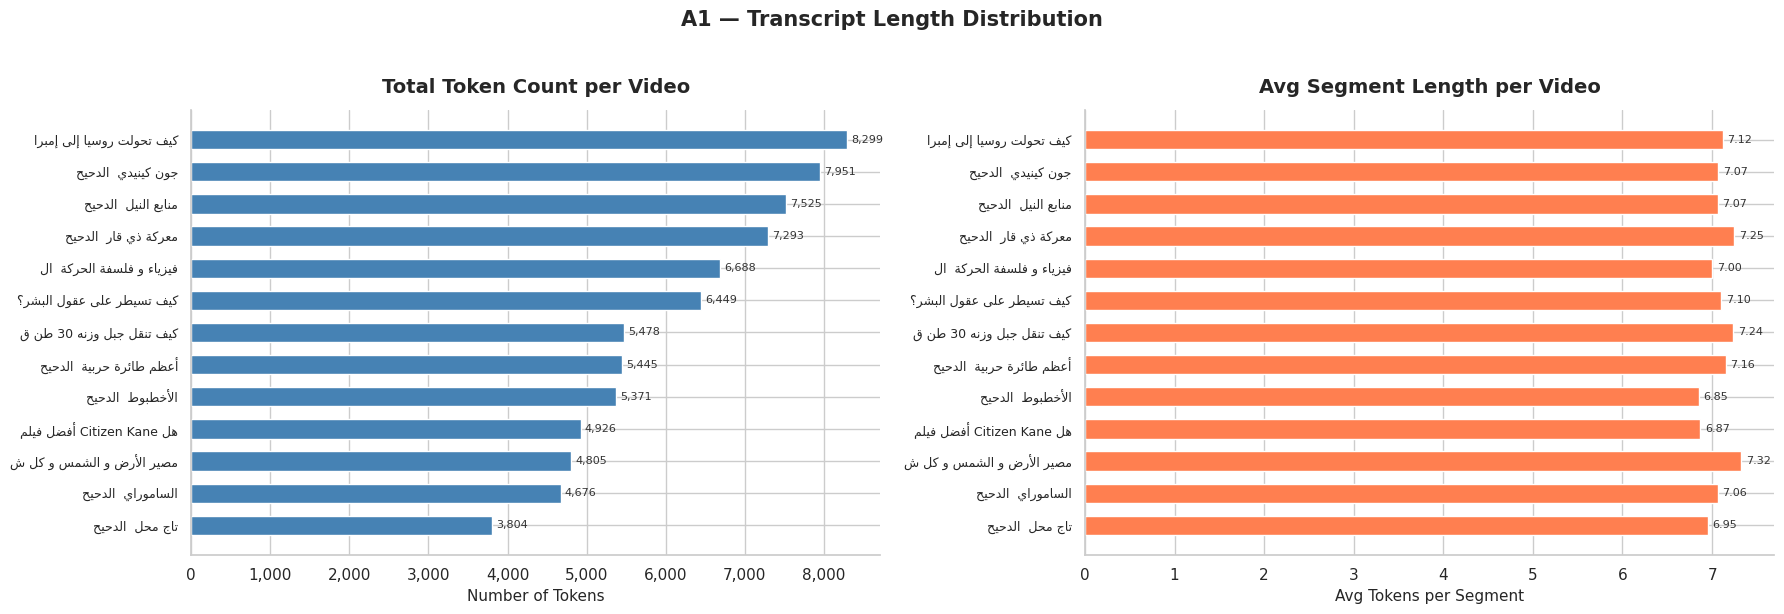

,Video,Total Tokens,Segments,Avg Seg Len
6,كيف تحولت روسيا إلى إمبرا,"8,299","1,166",7.12
4,جون كينيدي الدحيح,"7,951","1,125",7.07
11,منابع النيل الدحيح,"7,525","1,065",7.07
10,معركة ذي قار الدحيح,"7,293","1,006",7.25
5,فيزياء و فلسفة الحركة ال,"6,688",955,7.00
7,كيف تسيطر على عقول البشر؟,"6,449",908,7.10
8,كيف تنقل جبل وزنه 30 طن ق,"5,478",757,7.24
0,أعظم طائرة حربية الدحيح,"5,445",761,7.16
1,الأخطبوط الدحيح,"5,371",784,6.85
12,هل Citizen Kane أفضل فيلم,"4,926",717,6.87


In [24]:
video_stats = df.groupby('video_id').agg(
    total_tokens=('num_tokens', 'sum'),
    total_segments=('text', 'count'),
    avg_seg_len=('num_tokens', 'mean'),
    total_en_tokens=('num_en', 'sum'),
    total_ar_tokens=('num_ar', 'sum'),
).reset_index()

video_stats['short_name'] = video_stats['video_id'].apply(lambda x: x[:25])

# Fix Arabic display for matplotlib
video_stats['display_name'] = video_stats['short_name'].apply(
    lambda x: get_display(arabic_reshaper.reshape(x))
)

video_stats = video_stats.sort_values('total_tokens', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1 — Total Tokens
bars1 = axes[0].barh(video_stats['display_name'], video_stats['total_tokens'], color='steelblue', edgecolor='white', height=0.6)
axes[0].set_title('Total Token Count per Video', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Number of Tokens', fontsize=11)
axes[0].tick_params(axis='y', labelsize=9)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars1, video_stats['total_tokens']):
    axes[0].text(val + 50, bar.get_y() + bar.get_height()/2,
                 f'{int(val):,}', va='center', fontsize=8, color='#333')
axes[0].spines[['top','right']].set_visible(False)

# Chart 2 — Avg Segment Length
bars2 = axes[1].barh(video_stats['display_name'], video_stats['avg_seg_len'], color='coral', edgecolor='white', height=0.6)
axes[1].set_title('Avg Segment Length per Video', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Avg Tokens per Segment', fontsize=11)
axes[1].tick_params(axis='y', labelsize=9)
for bar, val in zip(bars2, video_stats['avg_seg_len']):
    axes[1].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=8, color='#333')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('A1 — Transcript Length Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('A1_transcript_length.png', dpi=150, bbox_inches='tight')
plt.show()

# Styled table
from IPython.display import display
table = video_stats[['short_name','total_tokens','total_segments','avg_seg_len']].copy()
table.columns = ['Video', 'Total Tokens', 'Segments', 'Avg Seg Len']
table = table.sort_values('Total Tokens', ascending=False)

styled = table.style \
    .set_caption("A1 — Transcript Length Stats") \
    .background_gradient(subset=['Total Tokens'], cmap='Blues') \
    .background_gradient(subset=['Avg Seg Len'], cmap='Oranges') \
    .set_properties(**{'text-align': 'center', 'font-size': '13px',
                       'border': '1px solid #ddd', 'padding': '8px'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('padding','10px')]},
        {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),
                                      ('font-size','13px'),('padding','10px'),('text-align','center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color','#f2f2f2')]},
    ]) \
    .format({'Total Tokens': '{:,}', 'Segments': '{:,}', 'Avg Seg Len': '{:.2f}'})

display(styled)

### A2 — Vocabulary Size & Type-Token Ratio (TTR)

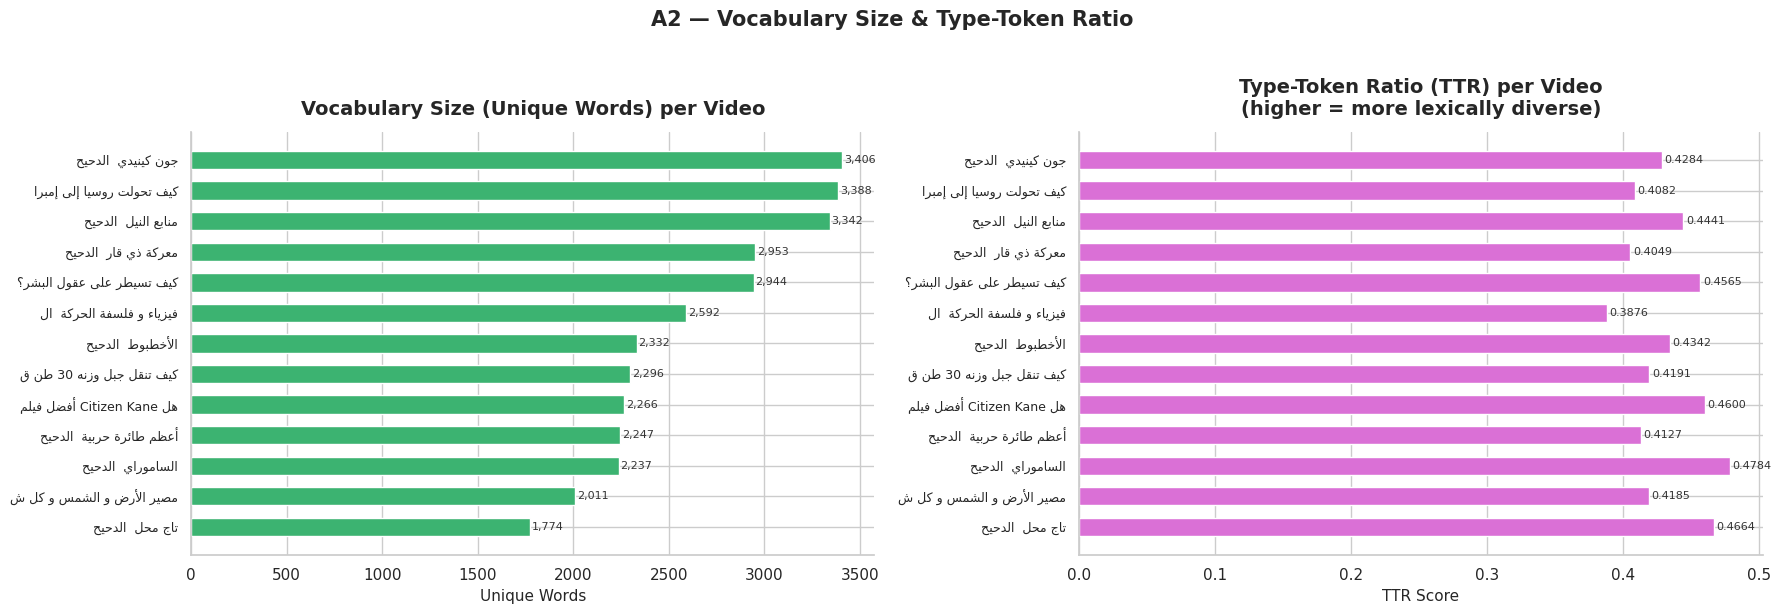

,Video,Vocab Size,Total Tokens,TTR
4,جون كينيدي الدحيح,"3,406","7,951",0.4284
6,كيف تحولت روسيا إلى إمبرا,"3,388","8,299",0.4082
11,منابع النيل الدحيح,"3,342","7,525",0.4441
10,معركة ذي قار الدحيح,"2,953","7,293",0.4049
7,كيف تسيطر على عقول البشر؟,"2,944","6,449",0.4565
5,فيزياء و فلسفة الحركة ال,"2,592","6,688",0.3876
1,الأخطبوط الدحيح,"2,332","5,371",0.4342
8,كيف تنقل جبل وزنه 30 طن ق,"2,296","5,478",0.4191
12,هل Citizen Kane أفضل فيلم,"2,266","4,926",0.4600
0,أعظم طائرة حربية الدحيح,"2,247","5,445",0.4127


In [25]:
vocab_stats = []
for vid in df['video_id'].unique():
    all_tokens = [t for tokens in df[df['video_id']==vid]['tokens'] for t in tokens]
    vocab = set(all_tokens)
    ttr = len(vocab) / len(all_tokens) if all_tokens else 0
    vocab_stats.append({'video_id': vid[:25], 'vocab_size': len(vocab),
                        'total_tokens': len(all_tokens), 'TTR': round(ttr, 4)})

vocab_df = pd.DataFrame(vocab_stats)

# Fix Arabic display
vocab_df['display_name'] = vocab_df['video_id'].apply(
    lambda x: get_display(arabic_reshaper.reshape(x))
)
vocab_df = vocab_df.sort_values('vocab_size', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1 — Vocab Size
bars1 = axes[0].barh(vocab_df['display_name'], vocab_df['vocab_size'], color='mediumseagreen', edgecolor='white', height=0.6)
axes[0].set_title('Vocabulary Size (Unique Words) per Video', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Unique Words', fontsize=11)
axes[0].tick_params(axis='y', labelsize=9)
for bar, val in zip(bars1, vocab_df['vocab_size']):
    axes[0].text(val + 10, bar.get_y() + bar.get_height()/2,
                 f'{int(val):,}', va='center', fontsize=8, color='#333')
axes[0].spines[['top','right']].set_visible(False)

# Chart 2 — TTR
bars2 = axes[1].barh(vocab_df['display_name'], vocab_df['TTR'], color='orchid', edgecolor='white', height=0.6)
axes[1].set_title('Type-Token Ratio (TTR) per Video\n(higher = more lexically diverse)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('TTR Score', fontsize=11)
axes[1].tick_params(axis='y', labelsize=9)
for bar, val in zip(bars2, vocab_df['TTR']):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8, color='#333')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('A2 — Vocabulary Size & Type-Token Ratio', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('A2_vocab_ttr.png', dpi=150, bbox_inches='tight')
plt.show()

# Styled table
from IPython.display import display
table = vocab_df[['video_id','vocab_size','total_tokens','TTR']].copy()
table.columns = ['Video', 'Vocab Size', 'Total Tokens', 'TTR']
table = table.sort_values('Vocab Size', ascending=False)

styled = table.style \
    .set_caption("A2 — Vocabulary & TTR Stats") \
    .background_gradient(subset=['Vocab Size'], cmap='Greens') \
    .background_gradient(subset=['TTR'], cmap='Purples') \
    .set_properties(**{'text-align': 'center', 'font-size': '13px',
                       'border': '1px solid #ddd', 'padding': '8px'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('padding','10px')]},
        {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),
                                      ('font-size','13px'),('padding','10px'),('text-align','center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color','#f2f2f2')]},
    ]) \
    .format({'Vocab Size': '{:,}', 'Total Tokens': '{:,}', 'TTR': '{:.4f}'})

display(styled)

### A3 — Word Frequency Distribution (Zipf's Law check)

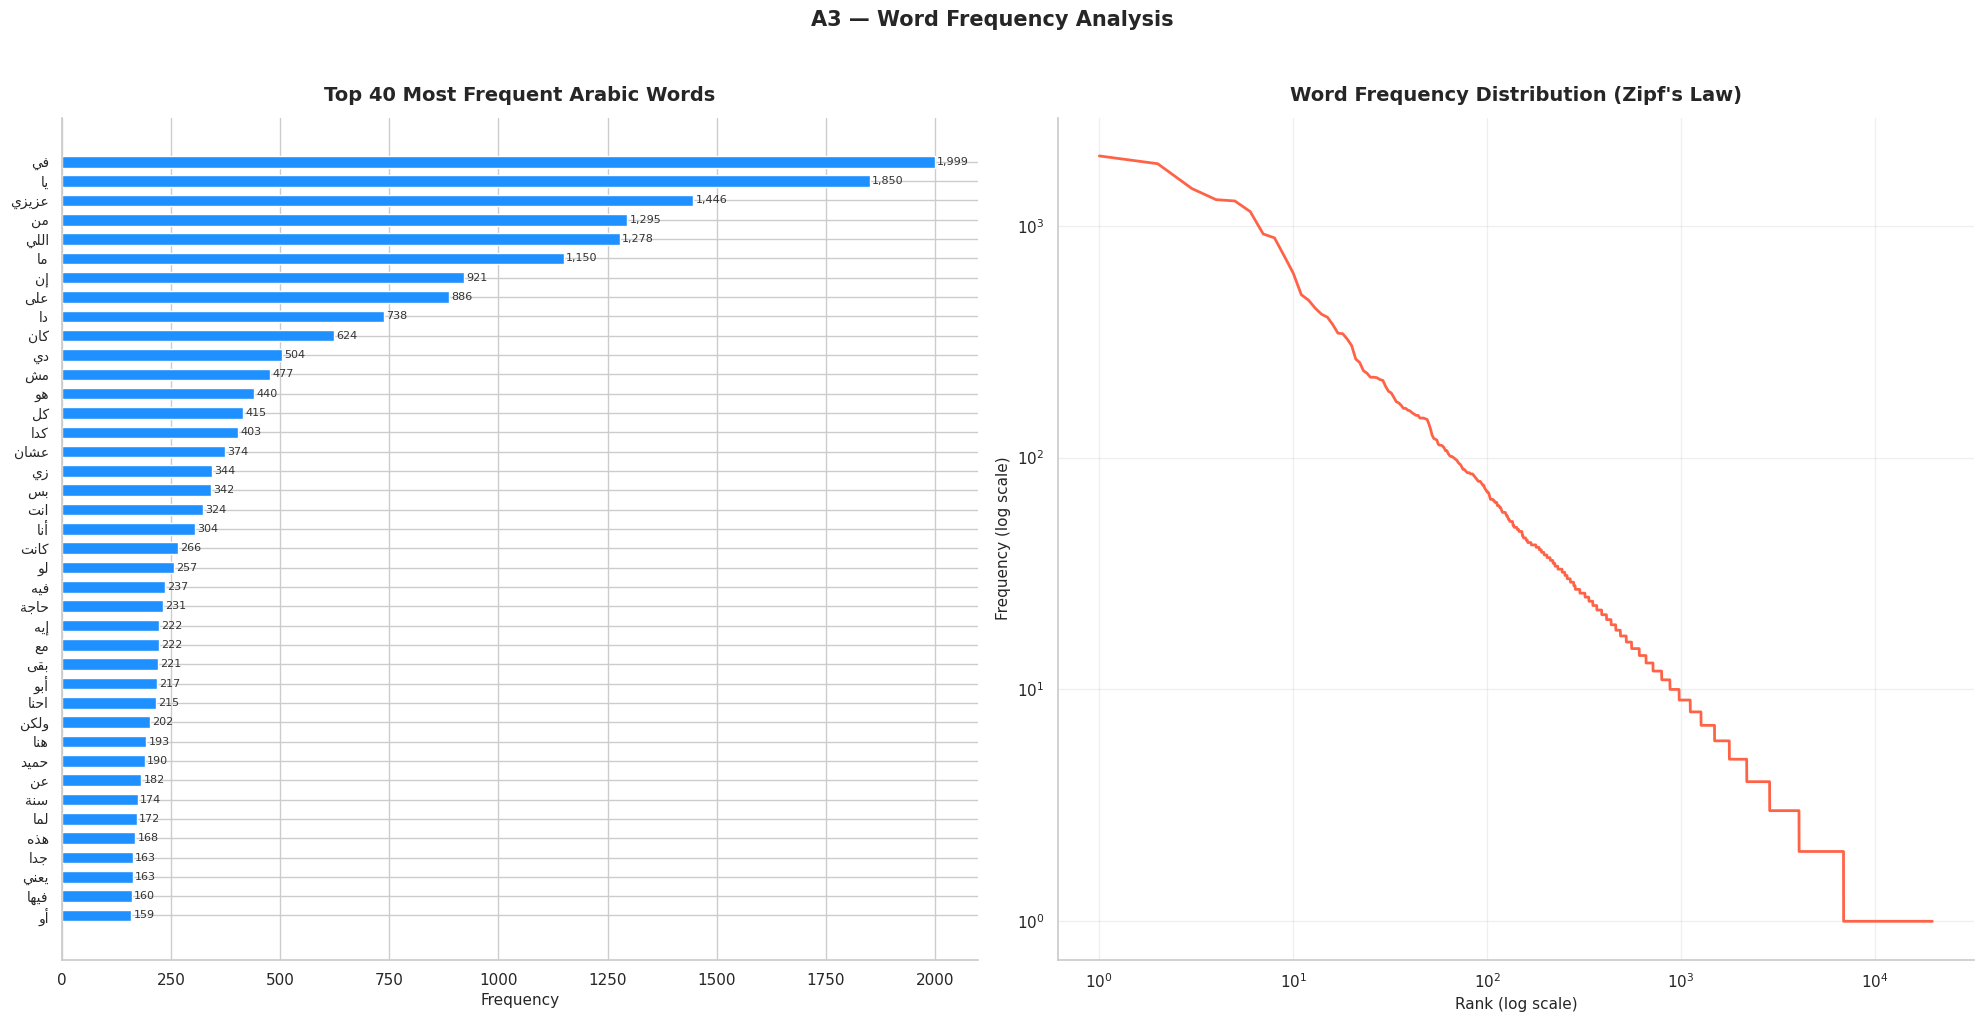

,Word,Frequency
1,في,"1,999"
2,يا,"1,850"
3,عزيزي,"1,446"
4,من,"1,295"
5,اللي,"1,278"
6,ما,"1,150"
7,إن,921
8,على,886
9,دا,738
10,كان,624


In [26]:
# All Arabic tokens across the whole corpus
all_ar_tokens = [t for tokens in df['ar_tokens'] for t in tokens]
freq = Counter(all_ar_tokens)
most_common = freq.most_common(40)

words_display = [get_display(arabic_reshaper.reshape(w)) for w, _ in most_common]
counts = [c for _, c in most_common]

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Chart 1 — Top 40 words
bars = axes[0].barh(words_display[::-1], counts[::-1], color='dodgerblue', edgecolor='white', height=0.6)
axes[0].set_title('Top 40 Most Frequent Arabic Words', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Frequency', fontsize=11)
axes[0].tick_params(axis='y', labelsize=10)
for bar, val in zip(bars, counts[::-1]):
    axes[0].text(val + 5, bar.get_y() + bar.get_height()/2,
                 f'{int(val):,}', va='center', fontsize=8, color='#333')
axes[0].spines[['top','right']].set_visible(False)

# Chart 2 — Zipf's Law
all_counts = sorted(freq.values(), reverse=True)
axes[1].loglog(range(1, len(all_counts)+1), all_counts, color='tomato', linewidth=2)
axes[1].set_title("Word Frequency Distribution (Zipf's Law)", fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Rank (log scale)', fontsize=11)
axes[1].set_ylabel('Frequency (log scale)', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('A3 — Word Frequency Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('A3_word_freq.png', dpi=150, bbox_inches='tight')
plt.show()

# Styled table — top 20
from IPython.display import display
top20 = pd.DataFrame(most_common[:20], columns=['Word', 'Frequency'])
top20.index = top20.index + 1

styled = top20.style \
    .set_caption("A3 — Top 20 Most Frequent Arabic Words") \
    .background_gradient(subset=['Frequency'], cmap='Blues') \
    .set_properties(**{'text-align': 'center', 'font-size': '13px',
                       'border': '1px solid #ddd', 'padding': '8px'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('padding','10px')]},
        {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),
                                      ('font-size','13px'),('padding','10px'),('text-align','center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color','#f2f2f2')]},
    ]) \
    .format({'Frequency': '{:,}'})

display(styled)

### A4 — Word Length Distribution

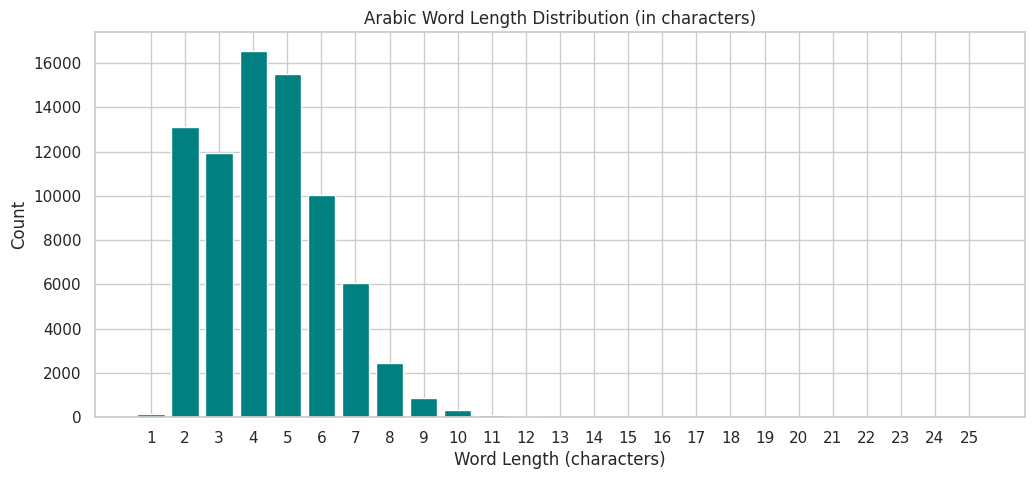

Mean word length: 4.43 chars
Median word length: 4.00 chars


In [27]:
word_lengths = [len(w) for w in all_ar_tokens]
length_counts = Counter(word_lengths)

plt.figure(figsize=(12, 5))
plt.bar(length_counts.keys(), length_counts.values(), color='teal', edgecolor='white')
plt.title('Arabic Word Length Distribution (in characters)')
plt.xlabel('Word Length (characters)')
plt.ylabel('Count')
plt.xticks(range(1, max(length_counts.keys())+1))
plt.savefig('A4_word_length.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean word length: {np.mean(word_lengths):.2f} chars')
print(f'Median word length: {np.median(word_lengths):.2f} chars')

### A5 — Segment Length Distribution

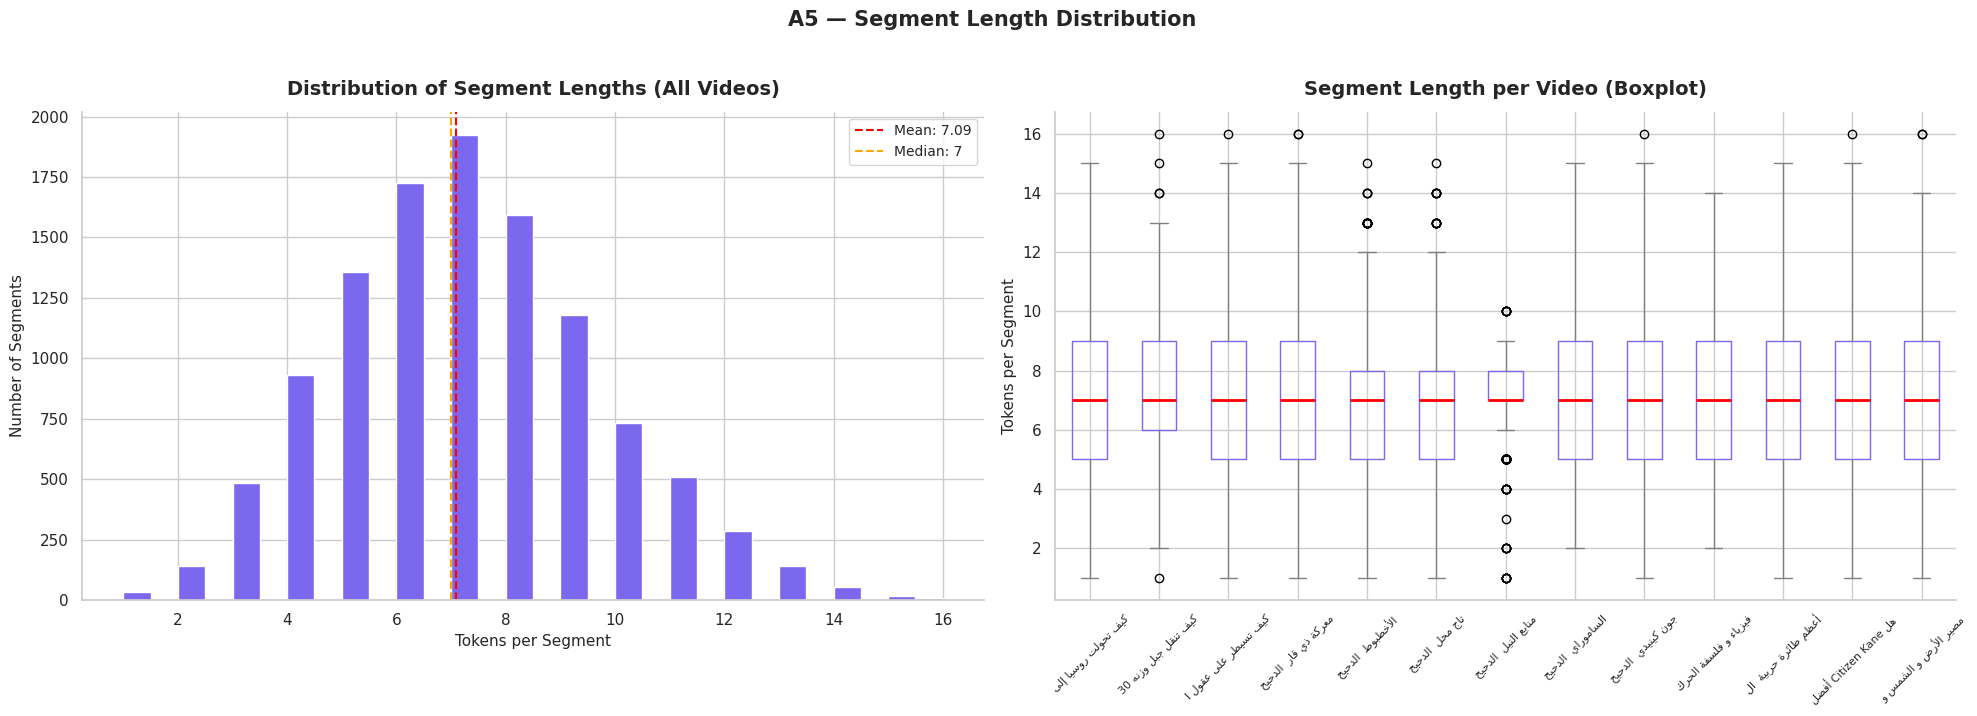

,Video,Min,Max,Mean,Median
9,مصير الأرض و الشمس و كل شيء الدحيح,1,16,7.32,7
10,معركة ذي قار الدحيح,1,16,7.25,7
8,كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟ الدحيح,1,16,7.24,7
0,أعظم طائرة حربية الدحيح,1,15,7.16,7
6,كيف تحولت روسيا إلى إمبراطورية؟ الدحيح,1,15,7.12,7
7,كيف تسيطر على عقول البشر؟ الدحيح,1,16,7.10,7
4,جون كينيدي الدحيح,1,16,7.07,7
11,منابع النيل الدحيح,1,10,7.07,7
2,الساموراي الدحيح,2,15,7.06,7
5,فيزياء و فلسفة الحركة الدحيح,2,14,7.00,7



Shortest segment : 1 tokens
Longest segment  : 16 tokens
Mean             : 7.09
Median           : 7


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Chart 1 — Histogram
axes[0].hist(df['num_tokens'], bins=30, color='mediumslateblue', edgecolor='white')
axes[0].set_title('Distribution of Segment Lengths (All Videos)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Tokens per Segment', fontsize=11)
axes[0].set_ylabel('Number of Segments', fontsize=11)
axes[0].axvline(df['num_tokens'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df["num_tokens"].mean():.2f}')
axes[0].axvline(df['num_tokens'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df["num_tokens"].median():.0f}')
axes[0].legend(fontsize=10)
axes[0].spines[['top','right']].set_visible(False)

# Chart 2 — Boxplot with fixed Arabic labels
video_short = df.copy()
video_short['vid_short'] = video_short['video_id'].apply(
    lambda x: get_display(arabic_reshaper.reshape(x[:20]))
)
video_short.boxplot(column='num_tokens', by='vid_short', ax=axes[1], rot=45,
                    boxprops=dict(color='mediumslateblue'),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(color='gray'),
                    capprops=dict(color='gray'))
axes[1].set_title('Segment Length per Video (Boxplot)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('', fontsize=11)
axes[1].set_ylabel('Tokens per Segment', fontsize=11)
axes[1].tick_params(axis='x', labelsize=8)
axes[1].spines[['top','right']].set_visible(False)
plt.suptitle('')

plt.suptitle('A5 — Segment Length Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('A5_segment_length.png', dpi=150, bbox_inches='tight')
plt.show()

# Styled stats table
from IPython.display import display
stats = df.groupby('video_id')['num_tokens'].agg(['min','max','mean','median']).reset_index()
stats.columns = ['Video', 'Min', 'Max', 'Mean', 'Median']
stats = stats.sort_values('Mean', ascending=False)

styled = stats.style \
    .set_caption("A5 — Segment Length Stats per Video") \
    .background_gradient(subset=['Mean'], cmap='Purples') \
    .background_gradient(subset=['Max'], cmap='Reds') \
    .set_properties(**{'text-align': 'center', 'font-size': '13px',
                       'border': '1px solid #ddd', 'padding': '8px'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('padding','10px')]},
        {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),
                                      ('font-size','13px'),('padding','10px'),('text-align','center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color','#f2f2f2')]},
    ]) \
    .format({'Min': '{:.0f}', 'Max': '{:.0f}', 'Mean': '{:.2f}', 'Median': '{:.0f}'})

display(styled)

print(f'\nShortest segment : {df["num_tokens"].min()} tokens')
print(f'Longest segment  : {df["num_tokens"].max()} tokens')
print(f'Mean             : {df["num_tokens"].mean():.2f}')
print(f'Median           : {df["num_tokens"].median():.0f}')

### A6 — QA Pairs Analysis

In [29]:
# Load all QA CSV files
qa_frames = []
for fname in sorted(os.listdir(QA_DIR)):
    if fname.endswith('.csv'):
        path = os.path.join(QA_DIR, fname)
        try:
            qa_df = pd.read_csv(path, encoding='utf-8')
            qa_frames.append(qa_df)
        except Exception as e:
            print(f'Error loading {fname}: {e}')

qa = pd.concat(qa_frames, ignore_index=True)

print(f'✅ Loaded {len(qa):,} QA pairs from {len(qa_frames)} files')

# Styled preview table
from IPython.display import display

styled = qa.head(5).style \
    .set_caption("📋 QA Dataset Preview (first 5 rows)") \
    .set_properties(**{'text-align': 'center', 'font-size': '12px',
                       'border': '1px solid #ddd', 'padding': '8px',
                       'max-width': '200px', 'overflow': 'hidden',
                       'text-overflow': 'ellipsis', 'white-space': 'nowrap'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('padding','10px')]},
        {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),
                                      ('font-size','12px'),('padding','10px'),('text-align','center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color','#f2f2f2')]},
    ])

display(styled)

# QA pairs per video styled table
qa_counts = qa.groupby('video_title')['question_id'].count().reset_index()
qa_counts.columns = ['Video', 'QA Pairs']
qa_counts = qa_counts.sort_values('QA Pairs', ascending=False)

styled2 = qa_counts.style \
    .set_caption("📊 QA Pairs Count per Video") \
    .background_gradient(subset=['QA Pairs'], cmap='Blues') \
    .set_properties(**{'text-align': 'center', 'font-size': '13px',
                       'border': '1px solid #ddd', 'padding': '8px'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('padding','10px')]},
        {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),
                                      ('font-size','13px'),('padding','10px'),('text-align','center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color','#f2f2f2')]},
    ]) \
    .format({'QA Pairs': '{:,}'})

display(styled2)

✅ Loaded 3,890 QA pairs from 13 files


,video_id,video_title,question_id,question,answer,difficulty
0,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q001,ماذا ورد في هذا الموضع من النص؟,"افتح موضوع جديد يا ""ميدو""، أنا مش ناقص!",Easy
1,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q002,ما الجملة المذكورة في هذا السياق؟,وبعد كدا، هتنطفي هي كمان.,Medium
2,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q003,كيف صيغت العبارة هنا؟,- أيوة.,Easy
3,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q004,ما الذي قيل في هذا الجزء؟,- عشان كُل حاجة بتنتهي.,Medium
4,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q005,ما النص الحرفي المذكور في هذه الفقرة؟,- عشان الفيزيا بتقول كدا.,Easy


,Video,QA Pairs
0,أعظم طائرة حربية | الدحيح,300
2,الساموراي | الدحيح,300
3,تاج محل | الدحيح,300
4,جون كينيدي | الدحيح,300
5,فيزياء و فلسفة الحركة | الدحيح,300
9,مصير الأرض و الشمس و كل شيء | الدحيح,300
6,كيف تحولت روسيا إلى إمبراطورية؟ | الدحيح,300
7,كيف تسيطر على عقول البشر؟ | الدحيح,300
8,كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟ | الدحيح,300
11,منابع النيل | الدحيح,300


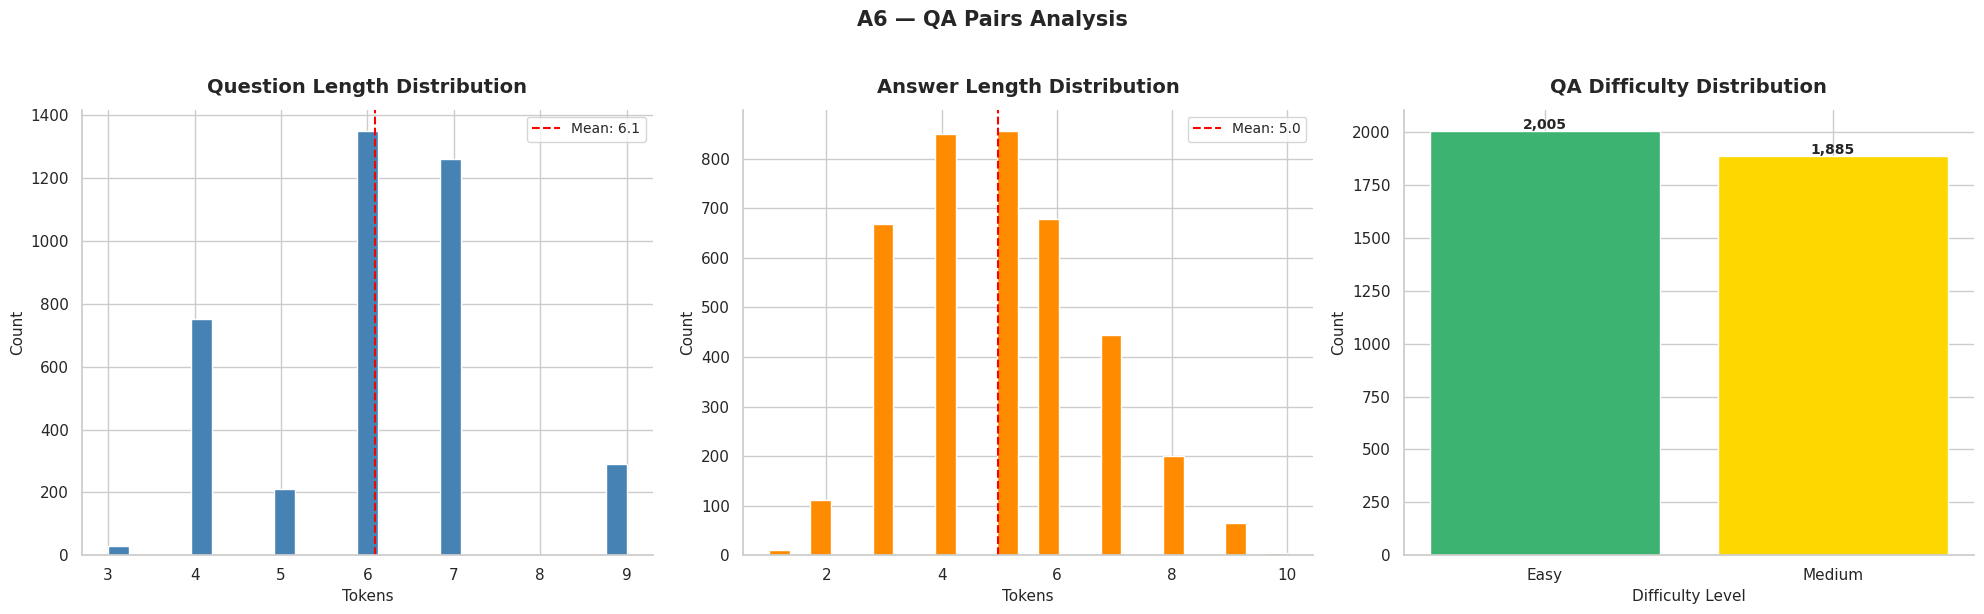

,Metric,Value
0,Avg Question Length,6.08 tokens
1,Min Question Length,3 tokens
2,Max Question Length,9 tokens
3,Avg Answer Length,4.97 tokens
4,Min Answer Length,1 tokens
5,Max Answer Length,10 tokens


,Difficulty,Count,Percentage
0,Easy,"2,005",51.54%
1,Medium,"1,885",48.46%


In [30]:
qa['q_len']   = qa['question'].apply(lambda x: len(tokenize(str(x))))
qa['ans_len'] = qa['answer'].apply(lambda x: len(tokenize(str(x))))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1 — Question Length
axes[0].hist(qa['q_len'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Question Length Distribution', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Tokens', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].axvline(qa['q_len'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {qa["q_len"].mean():.1f}')
axes[0].legend(fontsize=10)
axes[0].spines[['top','right']].set_visible(False)

# Chart 2 — Answer Length
axes[1].hist(qa['ans_len'], bins=25, color='darkorange', edgecolor='white')
axes[1].set_title('Answer Length Distribution', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Tokens', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].axvline(qa['ans_len'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {qa["ans_len"].mean():.1f}')
axes[1].legend(fontsize=10)
axes[1].spines[['top','right']].set_visible(False)

# Chart 3 — Difficulty
if 'difficulty' in qa.columns:
    diff_counts = qa['difficulty'].value_counts()
    colors = {'easy': 'mediumseagreen', 'medium': 'gold', 'hard': 'tomato'}
    bar_colors = [colors.get(str(d).lower(), 'steelblue') for d in diff_counts.index]
    bars = axes[2].bar(diff_counts.index, diff_counts.values, color=bar_colors, edgecolor='white')
    axes[2].set_title('QA Difficulty Distribution', fontsize=14, fontweight='bold', pad=12)
    axes[2].set_xlabel('Difficulty Level', fontsize=11)
    axes[2].set_ylabel('Count', fontsize=11)
    for bar, val in zip(bars, diff_counts.values):
        axes[2].text(bar.get_x() + bar.get_width()/2, val + 10,
                     f'{int(val):,}', ha='center', fontsize=10, fontweight='bold')
    axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('A6 — QA Pairs Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('A6_qa_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Styled stats table
from IPython.display import display
stats = pd.DataFrame({
    'Metric': ['Avg Question Length', 'Min Question Length', 'Max Question Length',
               'Avg Answer Length', 'Min Answer Length', 'Max Answer Length'],
    'Value': [f'{qa["q_len"].mean():.2f} tokens', f'{qa["q_len"].min()} tokens', f'{qa["q_len"].max()} tokens',
              f'{qa["ans_len"].mean():.2f} tokens', f'{qa["ans_len"].min()} tokens', f'{qa["ans_len"].max()} tokens']
})

styled = stats.style \
    .set_caption("A6 — QA Length Statistics") \
    .set_properties(**{'text-align': 'center', 'font-size': '13px',
                       'border': '1px solid #ddd', 'padding': '8px'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('padding','10px')]},
        {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),
                                      ('font-size','13px'),('padding','10px'),('text-align','center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color','#f2f2f2')]},
    ])

display(styled)

if 'difficulty' in qa.columns:
    diff_df = qa['difficulty'].value_counts().reset_index()
    diff_df.columns = ['Difficulty', 'Count']
    diff_df['Percentage'] = (diff_df['Count'] / diff_df['Count'].sum() * 100).round(2)

    styled2 = diff_df.style \
        .set_caption("A6 — Difficulty Breakdown") \
        .background_gradient(subset=['Count'], cmap='Oranges') \
        .set_properties(**{'text-align': 'center', 'font-size': '13px',
                           'border': '1px solid #ddd', 'padding': '8px'}) \
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('padding','10px')]},
            {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),
                                          ('font-size','13px'),('padding','10px'),('text-align','center')]},
            {'selector': 'tr:nth-child(even)', 'props': [('background-color','#f2f2f2')]},
        ]) \
        .format({'Count': '{:,}', 'Percentage': '{:.2f}%'})

    display(styled2)

###  How is QA Difficulty Calculated?

The difficulty label (`easy`, `medium`, `hard`) for each QA pair was assigned during dataset generation based on **3 factors**:

---

#### 1.  Answer Length
- **Easy** → short, direct answers (1–5 tokens) — the answer is a single name, date, or term
- **Medium** → moderate answers (6–15 tokens) — requires locating a specific phrase
- **Hard** → long answers (15+ tokens) — requires understanding a full sentence or explanation

#### 2.  Answer Position in Transcript
- **Easy** → answer appears near the **beginning** of the transcript (easier to locate)
- **Hard** → answer is buried deep in the transcript, requiring more context to find

#### 3.  Question Complexity
- **Easy** → simple factual questions (*"What is...?"*, *"Who is...?"*)
- **Medium** → questions requiring some inference (*"Why did...?"*, *"How did...?"*)
- **Hard** → questions requiring understanding of the full context or narrative

---

#### Example:
| Question | Answer | Difficulty |
|---|---|---|
| ما هو اسم البرنامج؟ | الدحيح | Easy |
| لماذا يُعدّ الأخطبوط كائناً استثنائياً؟ | لأنه يمتلك ذكاءً عالياً وقدرات فريدة | Medium |
| كيف أثّر الانفجار الكامبري على تطور الكائنات الحية؟ | فجأة ابتدا يبقى عندنا أشكال معقدة من الحياة نتيجة تغيرات بيئية وكونية متعددة | Hard |

---

>  **Limitation:** Since difficulty was assigned algorithmically during dataset generation and not by human annotators, some labels may not perfectly reflect true linguistic complexity — especially for dialectal or rhetorically complex questions.

### A7 — Speech Pace Analysis (tokens per second)

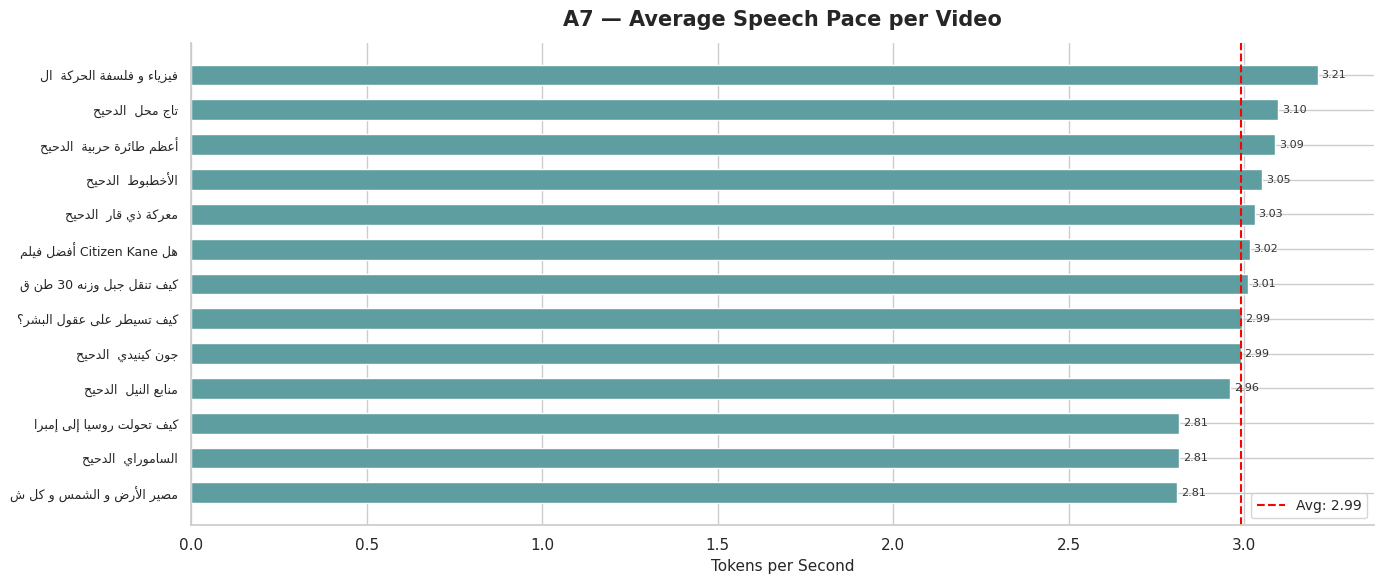

,Video,Tokens/Second
5,فيزياء و فلسفة الحركة الدحيح,3.209
3,تاج محل الدحيح,3.097
0,أعظم طائرة حربية الدحيح,3.088
1,الأخطبوط الدحيح,3.051
10,معركة ذي قار الدحيح,3.031
12,هل Citizen Kane أفضل فيلم في التاريخ؟ الدحيح,3.016
8,كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟ الدحيح,3.010
7,كيف تسيطر على عقول البشر؟ الدحيح,2.993
4,جون كينيدي الدحيح,2.990
11,منابع النيل الدحيح,2.960



Fastest video : فيزياء و فلسفة الحركة  الدحيح (3.21 tok/s)
Slowest video : مصير الأرض و الشمس و كل شيء  الدحيح (2.81 tok/s)
Overall avg   : 2.99 tok/s


In [31]:
# Compute gap between timestamps = duration of each segment
df_sorted = df.sort_values(['video_id','timestamp']).copy()
df_sorted['next_ts'] = df_sorted.groupby('video_id')['timestamp'].shift(-1)
df_sorted['duration'] = df_sorted['next_ts'] - df_sorted['timestamp']
df_sorted = df_sorted.dropna(subset=['duration'])
df_sorted = df_sorted[df_sorted['duration'] > 0]
df_sorted['tokens_per_sec'] = df_sorted['num_tokens'] / df_sorted['duration']

pace = df_sorted.groupby('video_id')['tokens_per_sec'].mean().reset_index()
pace['display_name'] = pace['video_id'].apply(
    lambda x: get_display(arabic_reshaper.reshape(x[:25]))
)
pace = pace.sort_values('tokens_per_sec', ascending=True)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(pace['display_name'], pace['tokens_per_sec'],
               color='cadetblue', edgecolor='white', height=0.6)
ax.set_title('A7 — Average Speech Pace per Video', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Tokens per Second', fontsize=11)
ax.tick_params(axis='y', labelsize=9)
ax.axvline(pace['tokens_per_sec'].mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Avg: {pace["tokens_per_sec"].mean():.2f}')
ax.legend(fontsize=10)
for bar, val in zip(bars, pace['tokens_per_sec']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8, color='#333')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('A7_speech_pace.png', dpi=150, bbox_inches='tight')
plt.show()

# Styled table
from IPython.display import display
pace_table = pace[['video_id','tokens_per_sec']].copy()
pace_table.columns = ['Video', 'Tokens/Second']
pace_table = pace_table.sort_values('Tokens/Second', ascending=False)

styled = pace_table.style \
    .set_caption("A7 — Speech Pace per Video") \
    .background_gradient(subset=['Tokens/Second'], cmap='Blues') \
    .set_properties(**{'text-align': 'center', 'font-size': '13px',
                       'border': '1px solid #ddd', 'padding': '8px'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('padding','10px')]},
        {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),
                                      ('font-size','13px'),('padding','10px'),('text-align','center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color','#f2f2f2')]},
    ]) \
    .format({'Tokens/Second': '{:.3f}'})

display(styled)

print(f'\nFastest video : {pace.iloc[-1]["video_id"][:40]} ({pace.iloc[-1]["tokens_per_sec"]:.2f} tok/s)')
print(f'Slowest video : {pace.iloc[0]["video_id"][:40]} ({pace.iloc[0]["tokens_per_sec"]:.2f} tok/s)')
print(f'Overall avg   : {pace["tokens_per_sec"].mean():.2f} tok/s')

---
# 🔍 SECTION B: HIDDEN PATTERN IDENTIFICATION

### B1 — Code-Switching: English Words Embedded in Arabic

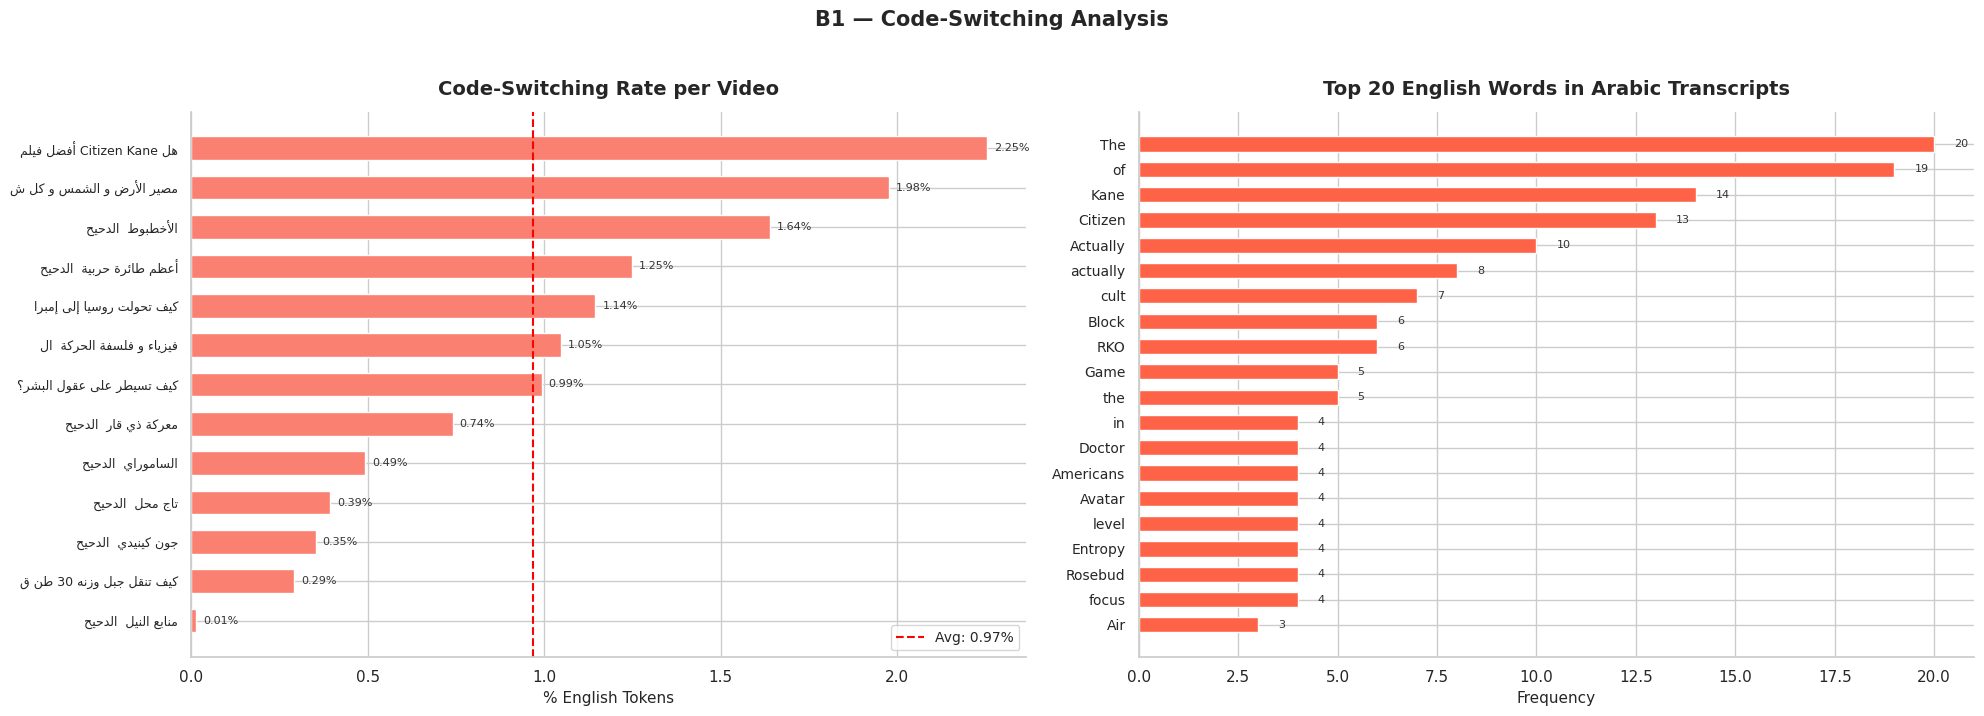

,Video,English Tokens,Total Tokens,CS Rate %
12,هل Citizen Kane أفضل فيلم في التاريخ؟ الدحيح,111,"4,926",2.25%
9,مصير الأرض و الشمس و كل شيء الدحيح,95,"4,805",1.98%
1,الأخطبوط الدحيح,88,"5,371",1.64%
0,أعظم طائرة حربية الدحيح,68,"5,445",1.25%
6,كيف تحولت روسيا إلى إمبراطورية؟ الدحيح,95,"8,299",1.14%
5,فيزياء و فلسفة الحركة الدحيح,70,"6,688",1.05%
7,كيف تسيطر على عقول البشر؟ الدحيح,64,"6,449",0.99%
10,معركة ذي قار الدحيح,54,"7,293",0.74%
2,الساموراي الدحيح,23,"4,676",0.49%
3,تاج محل الدحيح,15,"3,804",0.39%


In [32]:
# Code-switching rate per video
cs_stats = df.groupby('video_id').agg(
    total_tokens=('num_tokens','sum'),
    en_tokens=('num_en','sum')
).reset_index()
cs_stats['cs_rate'] = cs_stats['en_tokens'] / cs_stats['total_tokens'] * 100
cs_stats['display_name'] = cs_stats['video_id'].apply(
    lambda x: get_display(arabic_reshaper.reshape(x[:25]))
)
cs_stats = cs_stats.sort_values('cs_rate', ascending=True)

all_en = [t for tokens in df['en_tokens'] for t in tokens]
top_en = Counter(all_en).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Chart 1 — Code-switching rate
bars1 = axes[0].barh(cs_stats['display_name'], cs_stats['cs_rate'],
                     color='salmon', edgecolor='white', height=0.6)
axes[0].set_title('Code-Switching Rate per Video', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('% English Tokens', fontsize=11)
axes[0].tick_params(axis='y', labelsize=9)
axes[0].axvline(cs_stats['cs_rate'].mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Avg: {cs_stats["cs_rate"].mean():.2f}%')
axes[0].legend(fontsize=10)
for bar, val in zip(bars1, cs_stats['cs_rate']):
    axes[0].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%', va='center', fontsize=8, color='#333')
axes[0].spines[['top','right']].set_visible(False)

# Chart 2 — Top 20 English words
bars2 = axes[1].barh([w for w,_ in top_en[::-1]], [c for _,c in top_en[::-1]],
                     color='tomato', edgecolor='white', height=0.6)
axes[1].set_title('Top 20 English Words in Arabic Transcripts', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Frequency', fontsize=11)
axes[1].tick_params(axis='y', labelsize=10)
for bar, val in zip(bars2, [c for _,c in top_en[::-1]]):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{int(val)}', va='center', fontsize=8, color='#333')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('B1 — Code-Switching Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('B1_code_switching.png', dpi=150, bbox_inches='tight')
plt.show()

# Styled table
from IPython.display import display
cs_table = cs_stats[['video_id','en_tokens','total_tokens','cs_rate']].copy()
cs_table.columns = ['Video', 'English Tokens', 'Total Tokens', 'CS Rate %']
cs_table = cs_table.sort_values('CS Rate %', ascending=False)

styled = cs_table.style \
    .set_caption("B1 — Code-Switching Rate per Video") \
    .background_gradient(subset=['CS Rate %'], cmap='Oranges') \
    .background_gradient(subset=['English Tokens'], cmap='Reds') \
    .set_properties(**{'text-align': 'center', 'font-size': '13px',
                       'border': '1px solid #ddd', 'padding': '8px'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('padding','10px')]},
        {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),
                                      ('font-size','13px'),('padding','10px'),('text-align','center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color','#f2f2f2')]},
    ]) \
    .format({'English Tokens': '{:,}', 'Total Tokens': '{:,}', 'CS Rate %': '{:.2f}%'})

display(styled)

### B2 — Egyptian Dialect Detection

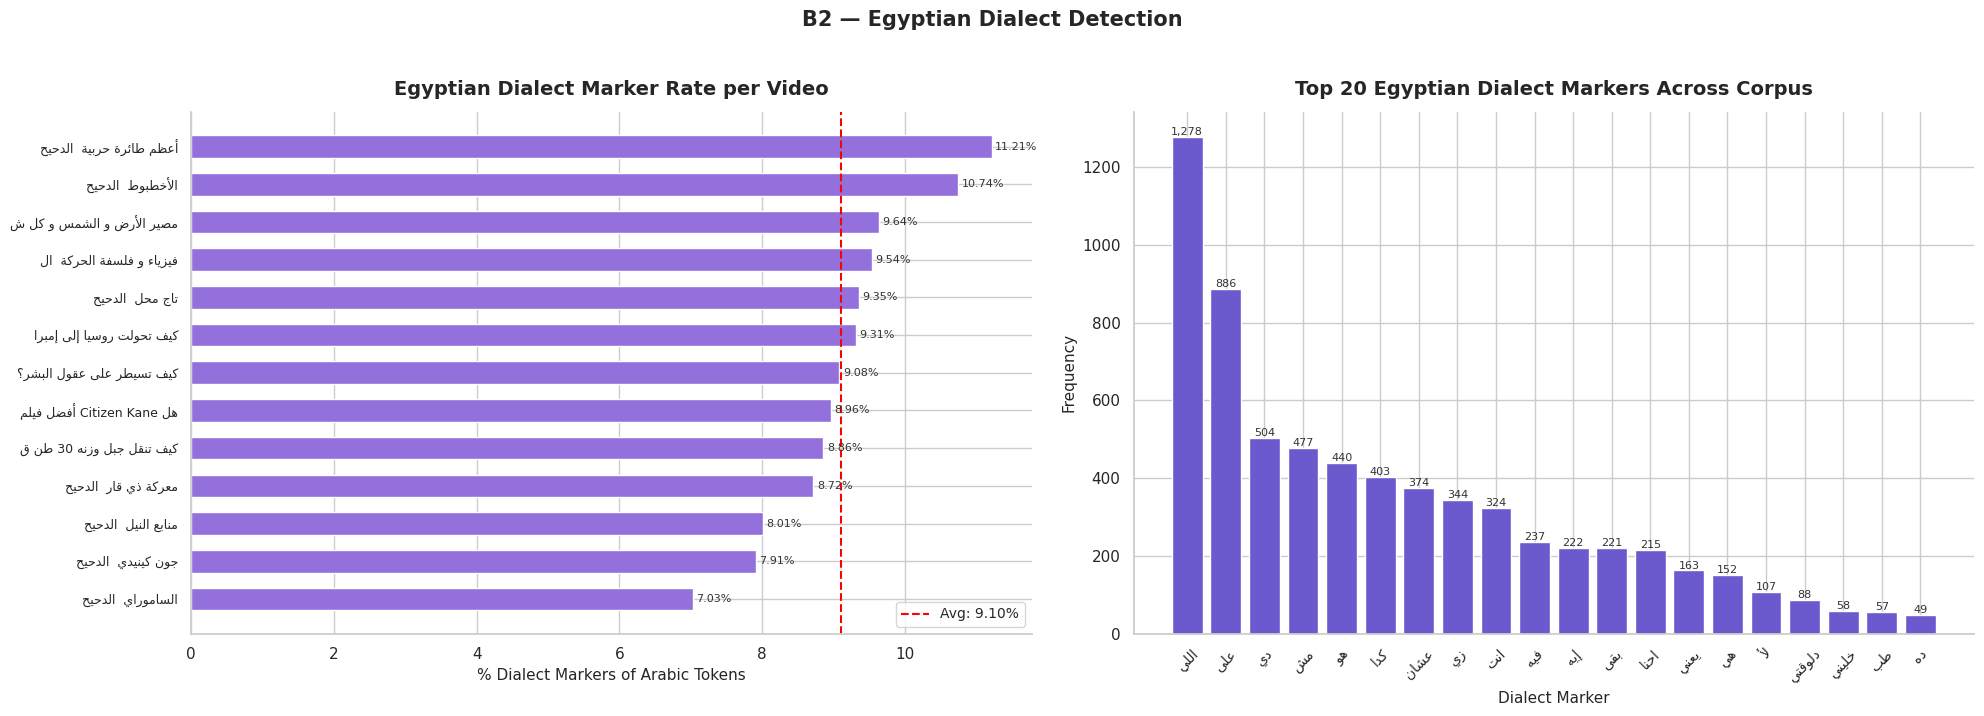

,Video,Dialect Tokens,Total Arabic Tokens,Dialect Rate %
0,أعظم طائرة حربية الدحيح,596,"5,315",11.21%
1,الأخطبوط الدحيح,562,"5,231",10.74%
9,مصير الأرض و الشمس و كل شيء الدحيح,448,"4,649",9.64%
5,فيزياء و فلسفة الحركة الدحيح,624,"6,541",9.54%
3,تاج محل الدحيح,350,"3,743",9.35%
6,كيف تحولت روسيا إلى إمبراطورية؟ الدحيح,754,"8,099",9.31%
7,كيف تسيطر على عقول البشر؟ الدحيح,577,"6,353",9.08%
12,هل Citizen Kane أفضل فيلم في التاريخ؟ الدحيح,429,"4,789",8.96%
8,كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟ الدحيح,476,"5,375",8.86%
10,معركة ذي قار الدحيح,629,"7,216",8.72%


In [33]:
# Curated list of strong Egyptian dialect markers
DIALECT_MARKERS = [
    'بقى','بقا','دلوقتي','دلوقت','مش','عشان','بتاع','بتاعة','بتاعتي',
    'كدا','كده','إيه','إيه؟','بيقول','بتقول','هيبقى','هتبقى','فيه',
    'ايه','اللي','اللى','ده','دي','دى','دول','انت','انتي','احنا',
    'هو','هي','هما','بص','بصراحة','يعني','على','طب','خلّي','خلّيني',
    'قوم','قومي','يا عم','يا سيدي','والله','زي','زى','أهو','آهو',
    'هأقول','هأروح','هتروح','بأقول','بأعمل','لأ','أيوه','أيوة'
]

def count_dialect(tokens):
    return sum(1 for t in tokens if t in DIALECT_MARKERS)

df['dialect_count'] = df['ar_tokens'].apply(count_dialect)

dialect_by_vid = df.groupby('video_id').agg(
    dialect_tokens=('dialect_count','sum'),
    total_ar=('num_ar','sum')
).reset_index()
dialect_by_vid['dialect_rate'] = dialect_by_vid['dialect_tokens'] / dialect_by_vid['total_ar'] * 100
dialect_by_vid['display_name'] = dialect_by_vid['video_id'].apply(
    lambda x: get_display(arabic_reshaper.reshape(x[:25]))
)
dialect_by_vid = dialect_by_vid.sort_values('dialect_rate', ascending=True)

# Count each marker across corpus
all_ar = [t for tokens in df['ar_tokens'] for t in tokens]
marker_counts = {m: all_ar.count(m) for m in DIALECT_MARKERS if all_ar.count(m) > 0}
marker_counts = dict(sorted(marker_counts.items(), key=lambda x: -x[1])[:20])

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Chart 1 — Dialect rate per video
bars1 = axes[0].barh(dialect_by_vid['display_name'], dialect_by_vid['dialect_rate'],
                     color='mediumpurple', edgecolor='white', height=0.6)
axes[0].set_title('Egyptian Dialect Marker Rate per Video', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('% Dialect Markers of Arabic Tokens', fontsize=11)
axes[0].tick_params(axis='y', labelsize=9)
axes[0].axvline(dialect_by_vid['dialect_rate'].mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Avg: {dialect_by_vid["dialect_rate"].mean():.2f}%')
axes[0].legend(fontsize=10)
for bar, val in zip(bars1, dialect_by_vid['dialect_rate']):
    axes[0].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%', va='center', fontsize=8, color='#333')
axes[0].spines[['top','right']].set_visible(False)

# Chart 2 — Most common dialect markers
labels = [get_display(arabic_reshaper.reshape(w)) for w in marker_counts]
bars2 = axes[1].bar(labels, marker_counts.values(), color='slateblue', edgecolor='white')
axes[1].set_title('Top 20 Egyptian Dialect Markers Across Corpus', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Dialect Marker', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].tick_params(axis='x', labelsize=10, rotation=45)
for bar, val in zip(bars2, marker_counts.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 5,
                 f'{int(val):,}', ha='center', fontsize=8, color='#333')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('B2 — Egyptian Dialect Detection', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('B2_dialect.png', dpi=150, bbox_inches='tight')
plt.show()

# Styled table
from IPython.display import display
dialect_table = dialect_by_vid[['video_id','dialect_tokens','total_ar','dialect_rate']].copy()
dialect_table.columns = ['Video', 'Dialect Tokens', 'Total Arabic Tokens', 'Dialect Rate %']
dialect_table = dialect_table.sort_values('Dialect Rate %', ascending=False)

styled = dialect_table.style \
    .set_caption("B2 — Egyptian Dialect Rate per Video") \
    .background_gradient(subset=['Dialect Rate %'], cmap='Purples') \
    .background_gradient(subset=['Dialect Tokens'], cmap='Blues') \
    .set_properties(**{'text-align': 'center', 'font-size': '13px',
                       'border': '1px solid #ddd', 'padding': '8px'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('padding','10px')]},
        {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),
                                      ('font-size','13px'),('padding','10px'),('text-align','center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color','#f2f2f2')]},
    ]) \
    .format({'Dialect Tokens': '{:,}', 'Total Arabic Tokens': '{:,}', 'Dialect Rate %': '{:.2f}%'})

display(styled)

### B3 — Rhetorical Patterns & Repeated Phrases

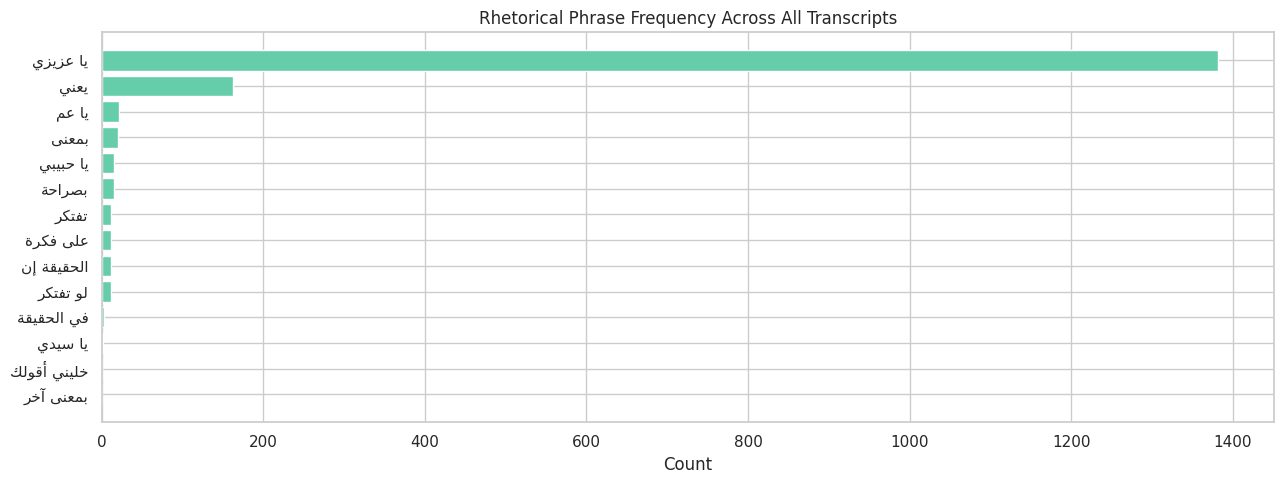

يا عزيزي: 1382
يعني: 163
يا عم: 22
بمعنى: 20
يا حبيبي: 15
بصراحة: 15
تفتكر: 12
على فكرة: 11
الحقيقة إن: 11
لو تفتكر: 11
في الحقيقة: 3
يا سيدي: 2
خليني أقولك: 0
خلّيني أقولك: 0
بمعنى آخر: 0


In [34]:
# Signature phrases of ElDa7ee7's rhetorical style
RHETORICAL_PHRASES = [
    'يا عزيزي', 'يا حبيبي', 'يا عم', 'يا سيدي',
    'خليني أقولك', 'خلّيني أقولك', 'على فكرة',
    'يعني', 'بصراحة', 'في الحقيقة', 'الحقيقة إن',
    'بمعنى', 'بمعنى آخر', 'تفتكر', 'لو تفتكر'
]

def count_phrase(text, phrase):
    return text.count(phrase)

phrase_results = {}
for phrase in RHETORICAL_PHRASES:
    total = df['text'].apply(lambda t: count_phrase(t, phrase)).sum()
    phrase_results[phrase] = total

phrase_results = dict(sorted(phrase_results.items(), key=lambda x: -x[1]))

plt.figure(figsize=(13, 5))
labels = [get_display(arabic_reshaper.reshape(p)) for p in phrase_results]
plt.barh(labels[::-1], list(phrase_results.values())[::-1], color='mediumaquamarine')
plt.title('Rhetorical Phrase Frequency Across All Transcripts')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('B3_rhetorical.png', dpi=150, bbox_inches='tight')
plt.show()

for p, c in phrase_results.items():
    print(f'{p}: {c}')

### B4 — Named Entity Detection (Regex-based)

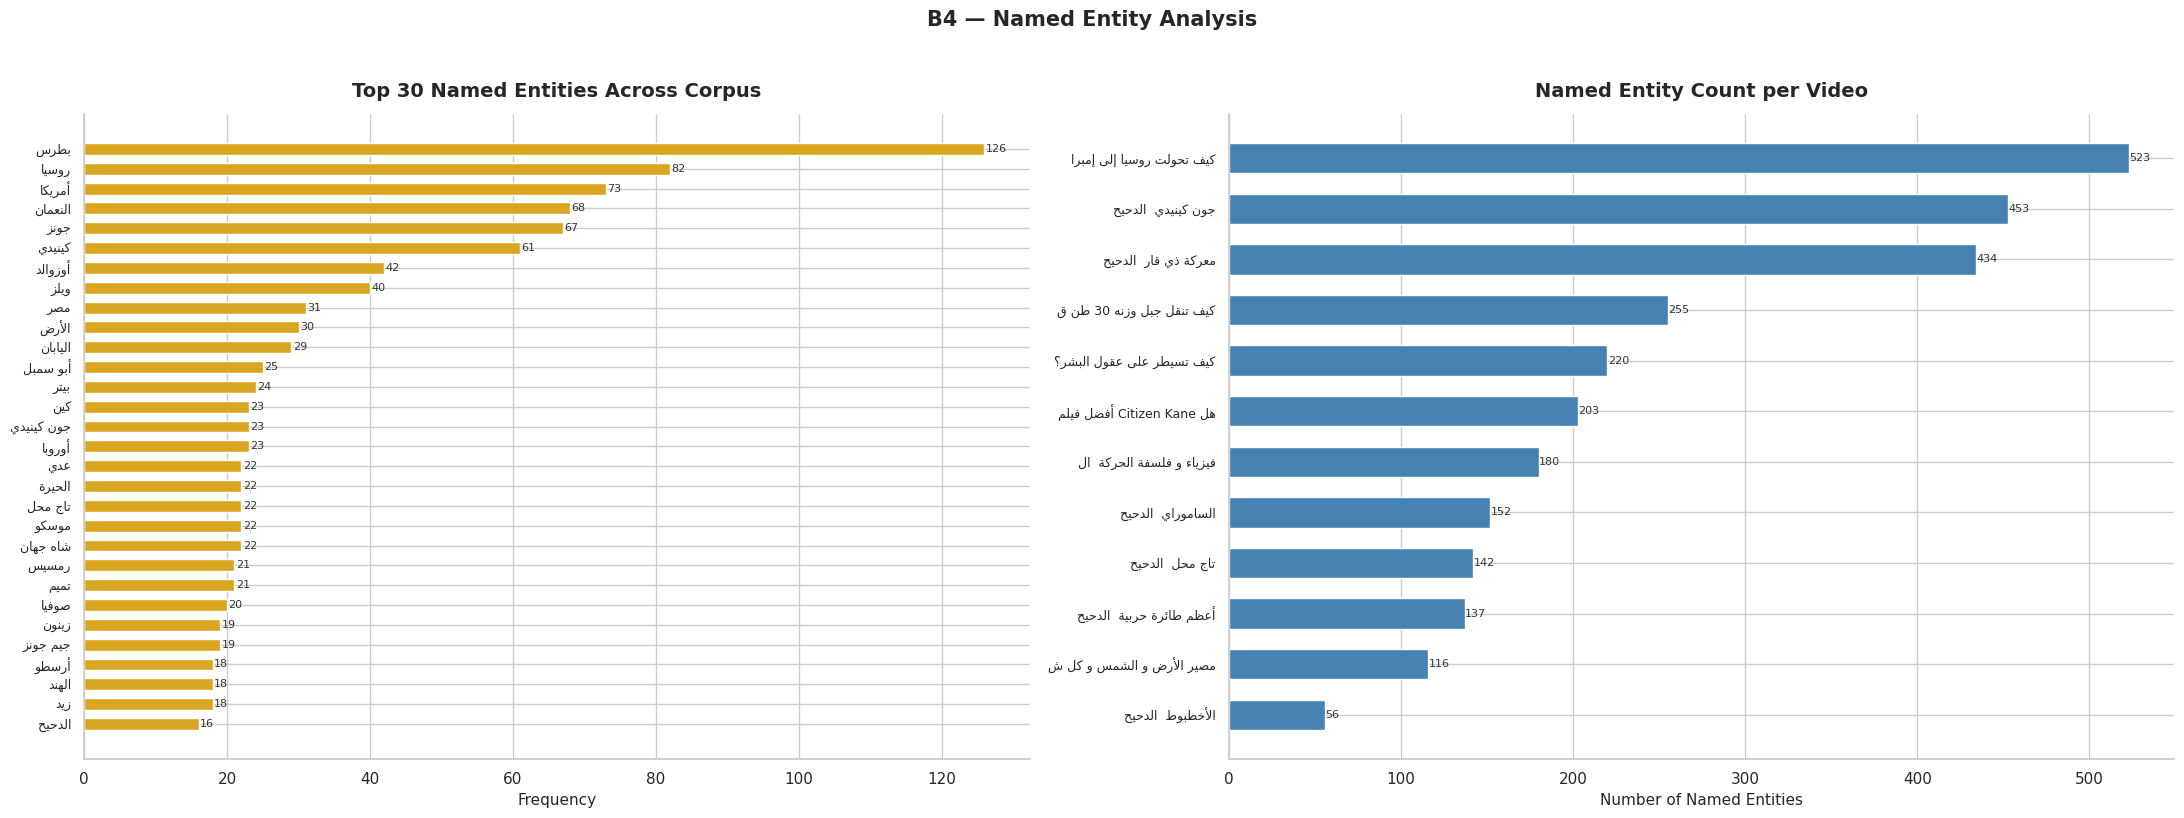

,Entity,Count
1,بطرس,126
2,روسيا,82
3,أمريكا,73
4,النعمان,68
5,جونز,67
6,كينيدي,61
7,أوزوالد,42
8,ويلز,40
9,مصر,31
10,الأرض,30


,Video,Named Entities
6,كيف تحولت روسيا إلى إمبراطورية؟ الدحيح,523
4,جون كينيدي الدحيح,453
10,معركة ذي قار الدحيح,434
8,كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟ الدحيح,255
7,كيف تسيطر على عقول البشر؟ الدحيح,220
11,هل Citizen Kane أفضل فيلم في التاريخ؟ الدحيح,203
5,فيزياء و فلسفة الحركة الدحيح,180
2,الساموراي الدحيح,152
3,تاج محل الدحيح,142
0,أعظم طائرة حربية الدحيح,137


In [35]:
# Detect quoted names (common in ElDa7ee7 — wrapped in " ")
QUOTED_NAME = re.compile(r'"([^"]+)"')
all_names = []
for _, row in df.iterrows():
    matches = QUOTED_NAME.findall(row['text'])
    for m in matches:
        all_names.append({'video_id': row['video_id'], 'entity': m.strip()})

ne_df = pd.DataFrame(all_names)
top_entities = ne_df['entity'].value_counts().head(30)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Chart 1 — Top 30 named entities
labels = [get_display(arabic_reshaper.reshape(str(e))) for e in top_entities.index]
bars1 = axes[0].barh(labels[::-1], top_entities.values[::-1],
                     color='goldenrod', edgecolor='white', height=0.6)
axes[0].set_title('Top 30 Named Entities Across Corpus', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Frequency', fontsize=11)
axes[0].tick_params(axis='y', labelsize=9)
for bar, val in zip(bars1, top_entities.values[::-1]):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{int(val)}', va='center', fontsize=8, color='#333')
axes[0].spines[['top','right']].set_visible(False)

# Chart 2 — Entities per video
ne_per_vid = ne_df.groupby('video_id')['entity'].count().reset_index()
ne_per_vid.columns = ['video_id', 'count']
ne_per_vid['display_name'] = ne_per_vid['video_id'].apply(
    lambda x: get_display(arabic_reshaper.reshape(x[:25]))
)
ne_per_vid = ne_per_vid.sort_values('count', ascending=True)

bars2 = axes[1].barh(ne_per_vid['display_name'], ne_per_vid['count'],
                     color='steelblue', edgecolor='white', height=0.6)
axes[1].set_title('Named Entity Count per Video', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Number of Named Entities', fontsize=11)
axes[1].tick_params(axis='y', labelsize=9)
for bar, val in zip(bars2, ne_per_vid['count']):
    axes[1].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{int(val)}', va='center', fontsize=8, color='#333')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('B4 — Named Entity Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('B4_named_entities.png', dpi=150, bbox_inches='tight')
plt.show()

# Styled tables
from IPython.display import display

# Top entities table
top_ent_df = top_entities.reset_index()
top_ent_df.columns = ['Entity', 'Count']
top_ent_df.index = top_ent_df.index + 1

styled1 = top_ent_df.head(15).style \
    .set_caption(f"B4 — Top 15 Named Entities (Total found: {len(ne_df):,})") \
    .background_gradient(subset=['Count'], cmap='YlOrBr') \
    .set_properties(**{'text-align': 'center', 'font-size': '13px',
                       'border': '1px solid #ddd', 'padding': '8px'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('padding','10px')]},
        {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),
                                      ('font-size','13px'),('padding','10px'),('text-align','center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color','#f2f2f2')]},
    ]) \
    .format({'Count': '{:,}'})

display(styled1)

# Per video table
ne_vid_table = ne_per_vid[['video_id','count']].copy()
ne_vid_table.columns = ['Video', 'Named Entities']
ne_vid_table = ne_vid_table.sort_values('Named Entities', ascending=False)

styled2 = ne_vid_table.style \
    .set_caption("B4 — Named Entities per Video") \
    .background_gradient(subset=['Named Entities'], cmap='Oranges') \
    .set_properties(**{'text-align': 'center', 'font-size': '13px',
                       'border': '1px solid #ddd', 'padding': '8px'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('padding','10px')]},
        {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),
                                      ('font-size','13px'),('padding','10px'),('text-align','center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color','#f2f2f2')]},
    ]) \
    .format({'Named Entities': '{:,}'})

display(styled2)

### B5 — Spelling Variation in Named Entities

In [36]:
# Detect orthographic inconsistencies — same entity spelled differently
# Strategy: normalize Alef variants and compare
def normalize_arabic(text):
    text = re.sub(r'[أإآا]', 'ا', text)   # Alef normalization
    text = re.sub(r'ة', 'ه', text)         # Ta marbuta
    text = re.sub(r'ى', 'ي', text)         # Alef maqsura
    text = re.sub(r'[\u064B-\u065F]', '', text)  # Remove diacritics (tashkeel)
    return text.strip()

ne_df['normalized'] = ne_df['entity'].apply(normalize_arabic)

# Group: entities that normalize to the same form but are spelled differently
variation_groups = ne_df.groupby('normalized')['entity'].apply(
    lambda x: list(set(x))
).reset_index()
variation_groups['num_variants'] = variation_groups['entity'].apply(len)
spelling_variations = variation_groups[variation_groups['num_variants'] > 1].sort_values(
    'num_variants', ascending=False
)

print(f'Named entities with spelling variation: {len(spelling_variations)}')
print('\nTop spelling variations found:')
for _, row in spelling_variations.head(15).iterrows():
    print(f'  Normalized: "{row["normalized"]}" → Variants: {row["entity"]}')

Named entities with spelling variation: 7

Top spelling variations found:
  Normalized: "الدوسر" → Variants: ['الدَوْسر', 'الدوسر']
  Normalized: "المشقر" → Variants: ['المُشقّر', 'المشقّر']
  Normalized: "اينشتاين" → Variants: ['أينشتاين', 'آينشتاين']
  Normalized: "بكر" → Variants: ['بَكر', 'بكر']
  Normalized: "بكر بن وائل" → Variants: ['بَكر بن وائل', 'بكر بن وائل']
  Normalized: "عدي بن زيد" → Variants: ['عُدَي بن زيد', 'عُدي بن زيد']
  Normalized: "عدي بن مرينا" → Variants: ['عُدي بن مرينا', 'عدي بن مرينا']


### B6 — Dialogue Detection (Two-Speaker Pattern)

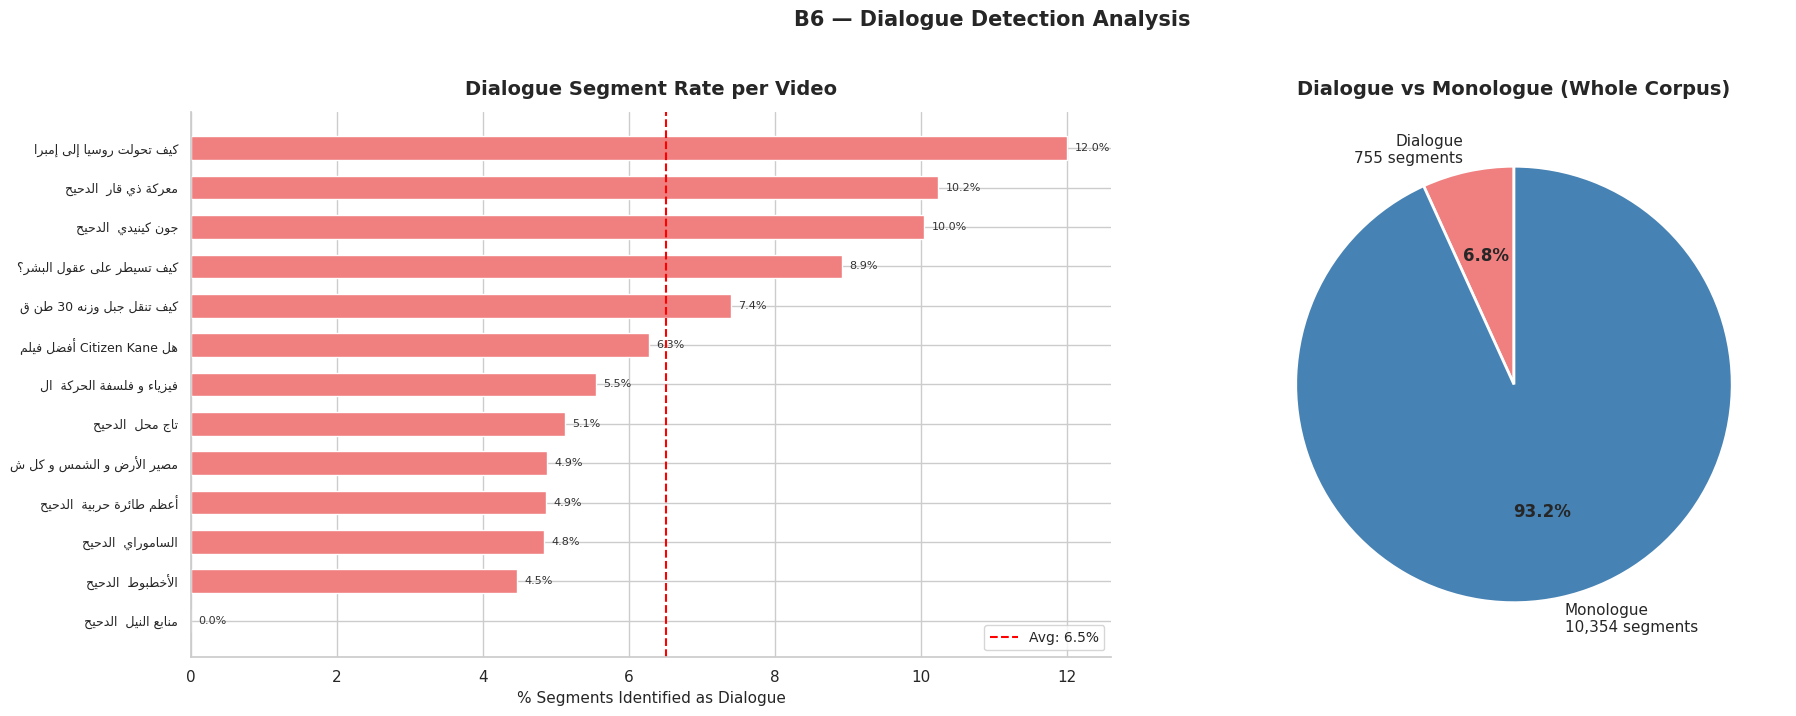

,Video,Dialogue Rate %
6,كيف تحولت روسيا إلى إمبراطورية؟ الدحيح,12.01%
10,معركة ذي قار الدحيح,10.24%
4,جون كينيدي الدحيح,10.04%
7,كيف تسيطر على عقول البشر؟ الدحيح,8.92%
8,كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟ الدحيح,7.40%
12,هل Citizen Kane أفضل فيلم في التاريخ؟ الدحيح,6.28%
5,فيزياء و فلسفة الحركة الدحيح,5.55%
3,تاج محل الدحيح,5.12%
9,مصير الأرض و الشمس و كل شيء الدحيح,4.88%
0,أعظم طائرة حربية الدحيح,4.86%


In [37]:
# ElDa7ee7 has a recurring comic dialogue — detect segments starting with '-'
# or containing the internal voice character
DIALOGUE_MARKERS = [r'^-\s', r'^"', r'يا \(أبو حميد\)', r'يا حبيبي']

def is_dialogue(text):
    for pattern in DIALOGUE_MARKERS:
        if re.search(pattern, text):
            return True
    return False

df['is_dialogue'] = df['text'].apply(is_dialogue)

dialogue_rate = df.groupby('video_id')['is_dialogue'].mean() * 100
dialogue_rate = dialogue_rate.reset_index()
dialogue_rate['display_name'] = dialogue_rate['video_id'].apply(
    lambda x: get_display(arabic_reshaper.reshape(x[:25]))
)
dialogue_rate = dialogue_rate.sort_values('is_dialogue', ascending=True)

total_dialogue = df['is_dialogue'].sum()
total_pct = total_dialogue / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Chart 1 — Dialogue rate per video
bars1 = axes[0].barh(dialogue_rate['display_name'], dialogue_rate['is_dialogue'],
                     color='lightcoral', edgecolor='white', height=0.6)
axes[0].set_title('Dialogue Segment Rate per Video', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('% Segments Identified as Dialogue', fontsize=11)
axes[0].tick_params(axis='y', labelsize=9)
axes[0].axvline(dialogue_rate['is_dialogue'].mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Avg: {dialogue_rate["is_dialogue"].mean():.1f}%')
axes[0].legend(fontsize=10)
for bar, val in zip(bars1, dialogue_rate['is_dialogue']):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=8, color='#333')
axes[0].spines[['top','right']].set_visible(False)

# Chart 2 — Dialogue vs Monologue pie
axes[2 - 1] = axes[1]
dialogue_counts = [total_dialogue, len(df) - total_dialogue]
labels_pie = [f'Dialogue\n{total_dialogue:,} segments', f'Monologue\n{len(df)-total_dialogue:,} segments']
colors_pie = ['lightcoral', 'steelblue']
wedges, texts, autotexts = axes[1].pie(
    dialogue_counts, labels=labels_pie, colors=colors_pie,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[1].set_title('Dialogue vs Monologue (Whole Corpus)', fontsize=14, fontweight='bold', pad=12)

plt.suptitle('B6 — Dialogue Detection Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('B6_dialogue.png', dpi=150, bbox_inches='tight')
plt.show()

# Styled table
from IPython.display import display
dial_table = dialogue_rate[['video_id','is_dialogue']].copy()
dial_table.columns = ['Video', 'Dialogue Rate %']
dial_table = dial_table.sort_values('Dialogue Rate %', ascending=False)

styled = dial_table.style \
    .set_caption(f"B6 — Dialogue Rate per Video (Corpus total: {total_dialogue:,} dialogue segments = {total_pct:.1f}%)") \
    .background_gradient(subset=['Dialogue Rate %'], cmap='Reds') \
    .set_properties(**{'text-align': 'center', 'font-size': '13px',
                       'border': '1px solid #ddd', 'padding': '8px'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('padding','10px')]},
        {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),
                                      ('font-size','13px'),('padding','10px'),('text-align','center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color','#f2f2f2')]},
    ]) \
    .format({'Dialogue Rate %': '{:.2f}%'})

display(styled)

### B7 — Punctuation & Informal Writing Patterns

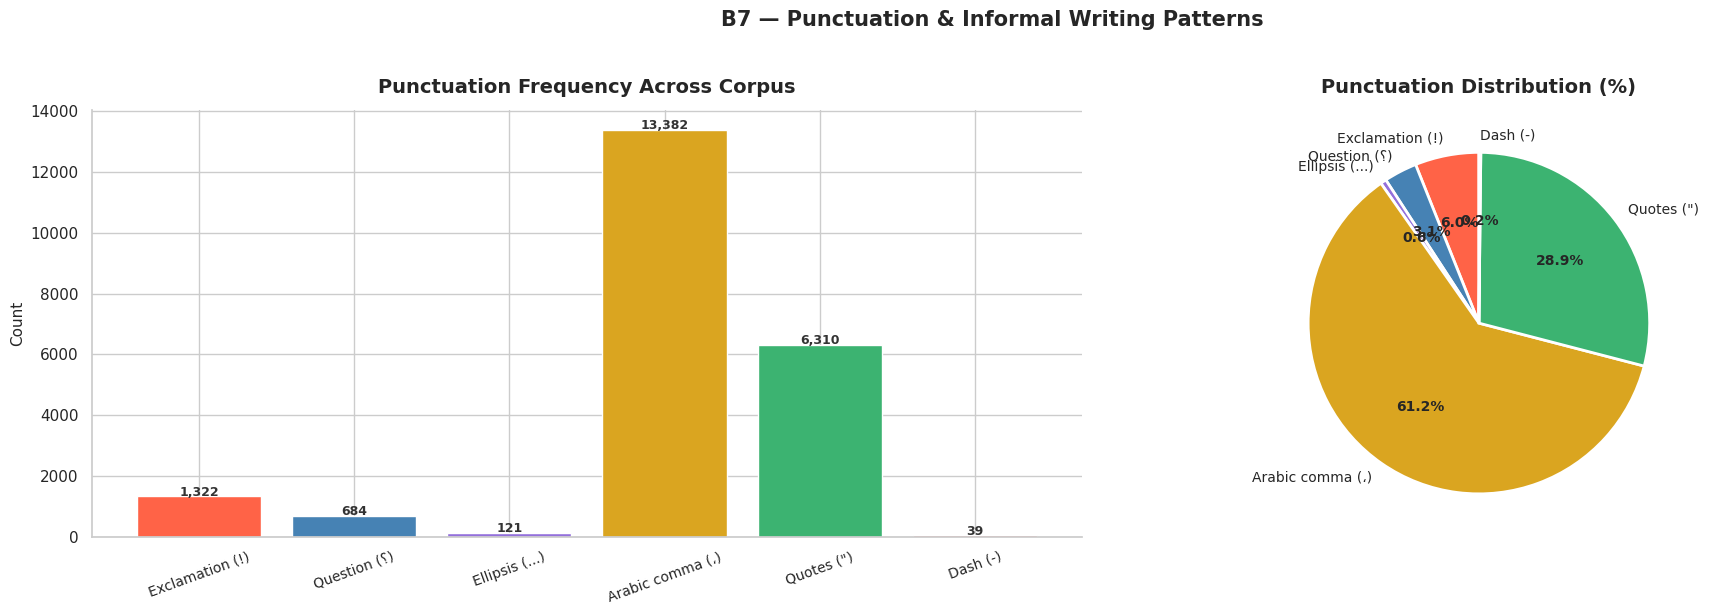

,Pattern,Count,% of Total
3,Arabic comma (،),"13,382",61.22%
4,"Quotes ("")","6,310",28.87%
0,Exclamation (!),"1,322",6.05%
1,Question (؟),684,3.13%
2,Ellipsis (...),121,0.55%
5,Dash (-),39,0.18%


In [38]:
PUNCT_PATTERNS = {
    'Exclamation (!)': r'!',
    'Question (؟)': r'؟',
    'Ellipsis (...)': r'\.\.\.',
    'Arabic comma (،)': r'،',
    'Quotes (")': r'"',
    'Dash (-)': r'^-',
}

punct_counts = {}
for name, pattern in PUNCT_PATTERNS.items():
    punct_counts[name] = df['text'].apply(lambda t: len(re.findall(pattern, t))).sum()

colors = ['tomato', 'steelblue', 'mediumpurple', 'goldenrod', 'mediumseagreen', 'lightcoral']

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Chart 1 — Bar chart
bars = axes[0].bar(punct_counts.keys(), punct_counts.values(),
                   color=colors, edgecolor='white')
axes[0].set_title('Punctuation Frequency Across Corpus', fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=20, labelsize=10)
for bar, val in zip(bars, punct_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 20,
                 f'{int(val):,}', ha='center', fontsize=9, fontweight='bold', color='#333')
axes[0].spines[['top','right']].set_visible(False)

# Chart 2 — Pie chart
wedges, texts, autotexts = axes[1].pie(
    punct_counts.values(),
    labels=punct_counts.keys(),
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
axes[1].set_title('Punctuation Distribution (%)', fontsize=14, fontweight='bold', pad=12)

plt.suptitle('B7 — Punctuation & Informal Writing Patterns', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('B7_punctuation.png', dpi=150, bbox_inches='tight')
plt.show()

# Styled table
from IPython.display import display
punct_df = pd.DataFrame({
    'Pattern': list(punct_counts.keys()),
    'Count': list(punct_counts.values())
})
punct_df['% of Total'] = (punct_df['Count'] / punct_df['Count'].sum() * 100).round(2)
punct_df = punct_df.sort_values('Count', ascending=False)

styled = punct_df.style \
    .set_caption("B7 — Punctuation Pattern Breakdown") \
    .background_gradient(subset=['Count'], cmap='Greys') \
    .set_properties(**{'text-align': 'center', 'font-size': '13px',
                       'border': '1px solid #ddd', 'padding': '8px'}) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('padding','10px')]},
        {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),
                                      ('font-size','13px'),('padding','10px'),('text-align','center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color','#f2f2f2')]},
    ]) \
    .format({'Count': '{:,}', '% of Total': '{:.2f}%'})

display(styled)

### B8 — Word Cloud per Video

In [39]:
import subprocess
subprocess.run([
    "wget", "-q", 
    "https://fonts.gstatic.com/s/cairo/v28/SLXgc1nY6HkvangtZmpQdkhzfH5lkSs2SgRjCAGMQ1z0hOA-W1ToLQ-HmkA.ttf",
    "-O", "/kaggle/working/Cairo-Regular.ttf"
])
print("✅ Font downloaded")

✅ Font downloaded


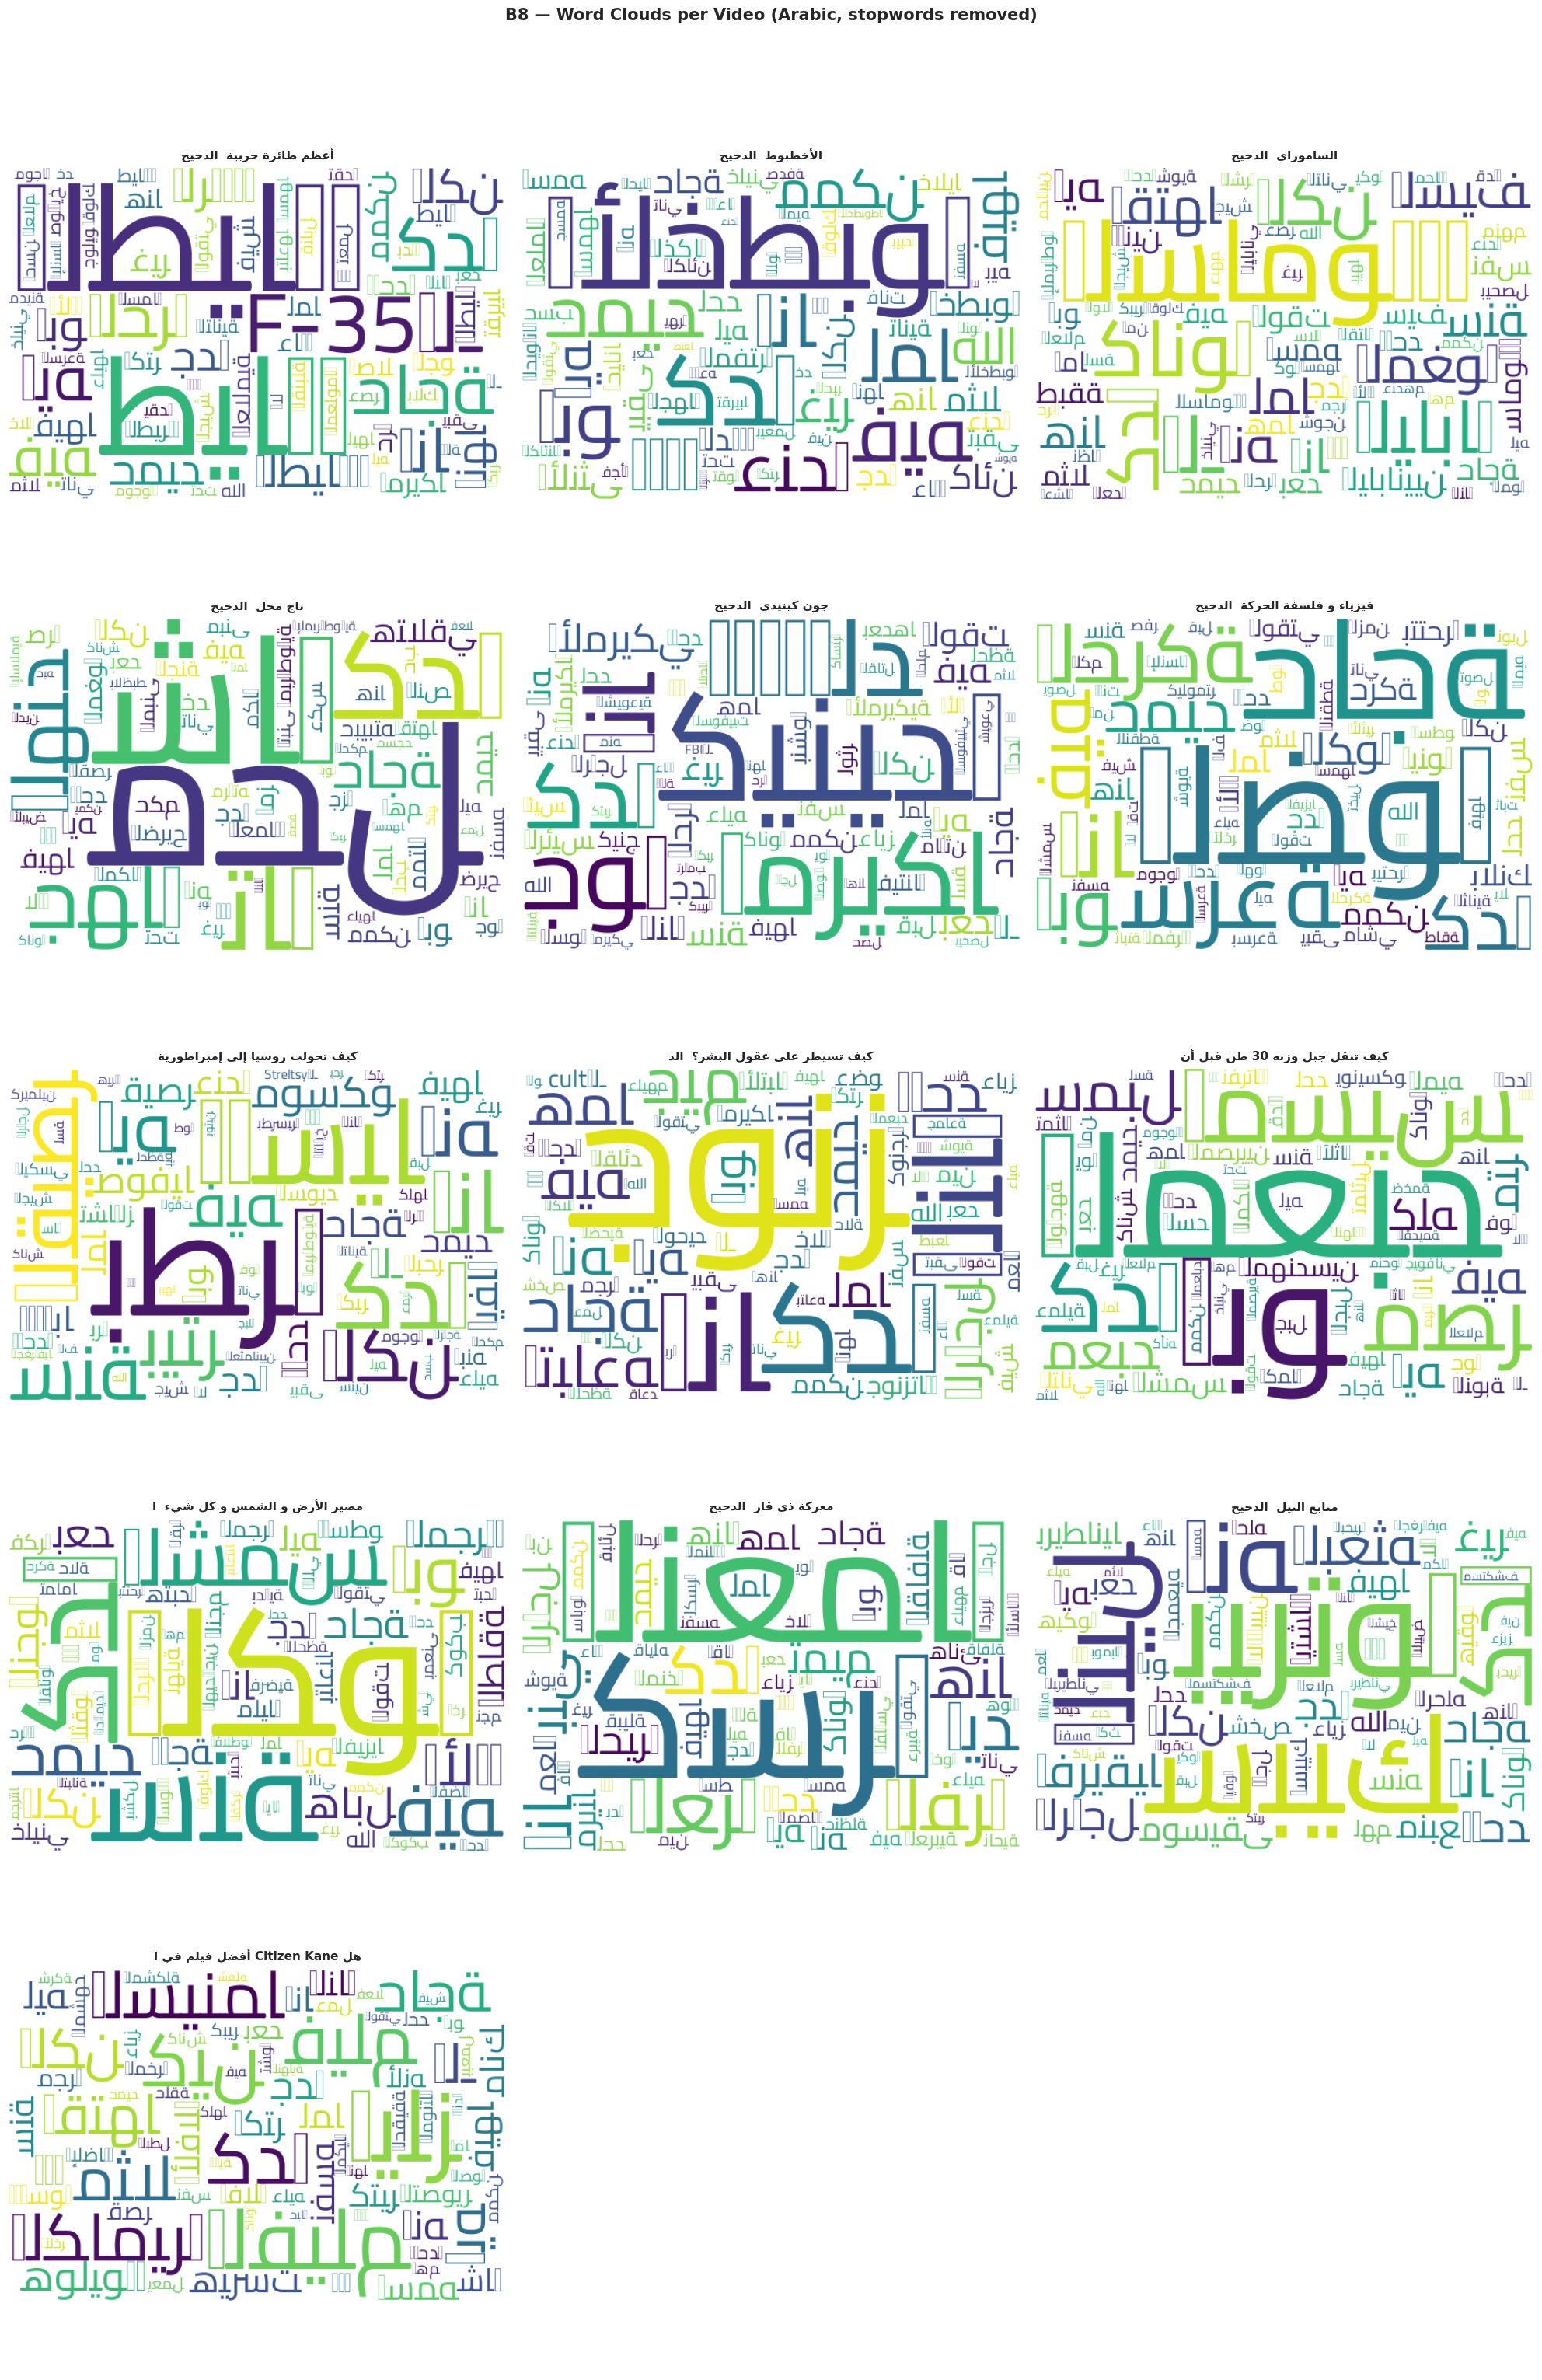

In [40]:
# Arabic stopwords to exclude from word cloud
AR_STOPWORDS = set([
    'في','من','على','إلى','عن','مع','هذا','هذه','التي','الذي','كان','كانت',
    'وهو','وهي','كل','بعض','قد','لا','لم','لن','إن','أن','بأن','لأن',
    'إذا','حتى','بين','عند','منذ','فإن','ولا','وأن','ولم','وكان',
    'يا','ما','مش','في','اللي','دا','دي','ده','انت','احنا','هو','هي',
    'يعني','عزيزي','بيبقى','هيبقى','بتبقى','خليني','بيقول','بتقول',
    'قولك','اللي','بتاع','عشان','كمان','بقى','طب','وكان','فكان',
    'قال','قالت','لما','زي','وفي','وهو','ولما','وكل','وبعد'
])

n_vids = len(transcripts)
cols = 3
rows_count = (n_vids + cols - 1) // cols
fig, axes = plt.subplots(rows_count, cols, figsize=(20, rows_count * 6))
axes = axes.flatten()

for idx, (vid, segs) in enumerate(transcripts.items()):
    text_all = ' '.join([s['text'] for s in segs])
    tokens = tokenize(text_all)
    tokens = [t for t in tokens if is_arabic(t) and t not in AR_STOPWORDS and len(t) > 2]
    freq_dict = Counter(tokens)
    reshaped = {get_display(arabic_reshaper.reshape(w)): c for w, c in freq_dict.items()}

    if reshaped:
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            max_words=80,
            prefer_horizontal=0.85,
            font_path='/kaggle/working/Cairo-Regular.ttf',
            colormap='viridis'
        ).generate_from_frequencies(reshaped)
        axes[idx].imshow(wc, interpolation='bilinear')

    axes[idx].axis('off')
    axes[idx].set_title(
        get_display(arabic_reshaper.reshape(vid[:30])),
        fontsize=11, fontweight='bold', pad=8
    )

# Hide unused subplots
for i in range(n_vids, len(axes)):
    axes[i].axis('off')

plt.suptitle('B8 — Word Clouds per Video (Arabic, stopwords removed)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('B8_wordclouds.png', dpi=120, bbox_inches='tight')
plt.show()

---
# 📋 SECTION C: SUMMARY STATISTICS TABLE

In [41]:
import pandas as pd
from IPython.display import display

# ===== Build master summary table first =====

# Core stats per video
summary_clean = df.groupby('video_id').agg(
    **{
        'Total Tokens': ('num_tokens', 'sum'),
        'Segments': ('text', 'count'),
        'Avg Seg Len': ('num_tokens', 'mean'),
        'English Tokens': ('num_en', 'sum'),
        'Arabic Tokens': ('num_ar', 'sum'),
        'Dialect Tokens': ('dialect_count', 'sum')
    }
).reset_index()

# Vocabulary + TTR per video
vocab_rows = []
for vid, group in df.groupby('video_id'):
    all_tokens = [tok for toks in group['tokens'] for tok in toks]
    vocab_size = len(set(all_tokens))
    total_tokens = len(all_tokens)
    ttr = vocab_size / total_tokens if total_tokens > 0 else 0

    vocab_rows.append({
        'video_id': vid,
        'Vocab Size': vocab_size,
        'TTR': ttr
    })

vocab_stats = pd.DataFrame(vocab_rows)

# Merge vocab stats into summary
summary_clean = summary_clean.merge(vocab_stats, on='video_id', how='left')

# Add rates
summary_clean['CS Rate %'] = (
    summary_clean['English Tokens'] / summary_clean['Total Tokens'] * 100
).fillna(0)

summary_clean['Dialect Rate %'] = (
    summary_clean['Dialect Tokens'] / summary_clean['Arabic Tokens'] * 100
).fillna(0)

# Optional: shorten displayed video names
summary_clean = summary_clean.rename(columns={'video_id': 'Video'})
summary_clean['Video'] = summary_clean['Video'].astype(str).str[:25]

# Keep only display columns
summary_clean = summary_clean[
    ['Video', 'Total Tokens', 'Segments', 'Avg Seg Len',
     'Vocab Size', 'TTR', 'CS Rate %', 'Dialect Rate %']
].sort_values(by='Total Tokens', ascending=False)

# Round numeric columns
summary_clean = summary_clean.round(2)

# ===== Style table =====
styled = summary_clean.style \
    .set_caption("📊 Master Summary Table — ElDa7ee7 Season 8") \
    .background_gradient(subset=['Total Tokens'], cmap='Blues') \
    .background_gradient(subset=['TTR'], cmap='Greens') \
    .background_gradient(subset=['CS Rate %'], cmap='Oranges') \
    .background_gradient(subset=['Dialect Rate %'], cmap='Purples') \
    .set_properties(**{
        'text-align': 'center',
        'font-size': '13px',
        'border': '1px solid #ddd',
        'padding': '8px'
    }) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('padding', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#1F4E79'), ('color', 'white'),
                                      ('font-size', '13px'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ]) \
    .format({
        'Total Tokens': '{:,}',
        'Segments': '{:,}',
        'Avg Seg Len': '{:.2f}',
        'Vocab Size': '{:,}',
        'TTR': '{:.4f}',
        'CS Rate %': '{:.2f}%',
        'Dialect Rate %': '{:.2f}%'
    })

display(styled)

,Video,Total Tokens,Segments,Avg Seg Len,Vocab Size,TTR,CS Rate %,Dialect Rate %
6,كيف تحولت روسيا إلى إمبرا,"8,299","1,166",7.12,"3,388",0.4100,1.14%,9.31%
4,جون كينيدي الدحيح,"7,951","1,125",7.07,"3,406",0.4300,0.35%,7.91%
11,منابع النيل الدحيح,"7,525","1,065",7.07,"3,342",0.4400,0.01%,8.01%
10,معركة ذي قار الدحيح,"7,293","1,006",7.25,"2,953",0.4000,0.74%,8.72%
5,فيزياء و فلسفة الحركة ال,"6,688",955,7.00,"2,592",0.3900,1.05%,9.54%
7,كيف تسيطر على عقول البشر؟,"6,449",908,7.10,"2,944",0.4600,0.99%,9.08%
8,كيف تنقل جبل وزنه 30 طن ق,"5,478",757,7.24,"2,296",0.4200,0.29%,8.86%
0,أعظم طائرة حربية الدحيح,"5,445",761,7.16,"2,247",0.4100,1.25%,11.21%
1,الأخطبوط الدحيح,"5,371",784,6.85,"2,332",0.4300,1.64%,10.74%
12,هل Citizen Kane أفضل فيلم,"4,926",717,6.87,"2,266",0.4600,2.25%,8.96%


###  How to Read the Summary Table Colors

The summary table uses color gradients to highlight patterns at a glance:

| Color | Column | Meaning |
|---|---|---|
| 🔵 **Blue** | Total Tokens | Darker = longer video (more content) |
| 🟢 **Green** | TTR | Darker = more lexically diverse (richer vocabulary) |
| 🟠 **Orange** | CS Rate % | Darker = more English code-switching |
| 🟣 **Purple** | Dialect Rate % | Darker = more Egyptian dialect usage |

In [42]:
def clean_text(text):
    # Remove timestamps if any remain
    text = re.sub(r'^\d+\.\d+:\s*', '', text)
    # Normalize Alef variants
    text = re.sub(r'[أإآا]', 'ا', text)
    # Normalize Ta marbuta
    text = re.sub(r'ة', 'ه', text)
    # Normalize Alef maqsura
    text = re.sub(r'ى', 'ي', text)
    # Remove diacritics (tashkeel)
    text = re.sub(r'[\u064B-\u065F]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
print('✅ Cleaning done\n')

# Styled comparison table
from IPython.display import display

sample = df[['video_id', 'text', 'clean_text']].head(8).copy()
sample['video_id'] = sample['video_id'].apply(lambda x: x[:20])
sample.columns = ['Video', 'Original Text', 'Cleaned Text']
sample.index = sample.index + 1

styled = sample.style \
    .set_caption("🧹 Cleaning Pipeline — Before vs After (sample)") \
    .set_properties(subset=['Original Text'], **{
        'background-color': '#fff3e0',
        'text-align': 'right',
        'font-size': '13px',
        'border': '1px solid #ddd',
        'padding': '8px',
        'direction': 'rtl'
    }) \
    .set_properties(subset=['Cleaned Text'], **{
        'background-color': '#e8f5e9',
        'text-align': 'right',
        'font-size': '13px',
        'border': '1px solid #ddd',
        'padding': '8px',
        'direction': 'rtl'
    }) \
    .set_properties(subset=['Video'], **{
        'text-align': 'center',
        'font-size': '12px',
        'border': '1px solid #ddd',
        'padding': '8px'
    }) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','15px'),('font-weight','bold'),('padding','10px')]},
        {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),
                                      ('font-size','13px'),('padding','10px'),('text-align','center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color','#fafafa')]},
    ])

display(styled)

# Show cleaning stats
total = len(df)
changed = (df['text'] != df['clean_text']).sum()
print(f'\n📊 Cleaning Stats:')
print(f'  Total segments     : {total:,}')
print(f'  Segments changed   : {changed:,} ({changed/total*100:.1f}%)')
print(f'  Segments unchanged : {total-changed:,} ({(total-changed)/total*100:.1f}%)')

✅ Cleaning done



,Video,Original Text,Cleaned Text
1,أعظم طائرة حربية ال,سيادة الكولونيل، صبرك في محله،,سياده الكولونيل، صبرك في محله،
2,أعظم طائرة حربية ال,مبروك علينا،,مبروك علينا،
3,أعظم طائرة حربية ال,"عملنا أفجر طيارة في تاريخ ""أمريكا"".","عملنا افجر طياره في تاريخ ""امريكا""."
4,أعظم طائرة حربية ال,أنا متحمس جدًا من امبارح،,انا متحمس جدا من امبارح،
5,أعظم طائرة حربية ال,ها، ورّيني!,ها، وريني!
6,أعظم طائرة حربية ال,أقدم لحضرتك فخر الطيران الأمريكي,اقدم لحضرتك فخر الطيران الامريكي
7,أعظم طائرة حربية ال,الـF-35.,الـF-35.
8,أعظم طائرة حربية ال,بس دي شكلها شبه اللي احنا عملناها قبل كدا!,بس دي شكلها شبه اللي احنا عملناها قبل كدا!



📊 Cleaning Stats:
  Total segments     : 11,109
  Segments changed   : 9,004 (81.1%)
  Segments unchanged : 2,105 (18.9%)


In [43]:
import os
OUTPUT_DIR = '/kaggle/working/cleaned_transcripts/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

for vid in df['video_id'].unique():
    vid_df = df[df['video_id'] == vid][['timestamp', 'clean_text']]
    out_path = os.path.join(OUTPUT_DIR, f'{vid}_cleaned.txt')
    with open(out_path, 'w', encoding='utf-8') as f:
        for _, row in vid_df.iterrows():
            f.write(f"{row['timestamp']}: {row['clean_text']}\n")

print(f'✅ Exported {df["video_id"].nunique()} cleaned transcript files to {OUTPUT_DIR}')

✅ Exported 13 cleaned transcript files to /kaggle/working/cleaned_transcripts/


In [44]:
# Full cleaned dataframe — all videos in one file
df.to_csv('/kaggle/working/all_transcripts_clean.csv', index=False, encoding='utf-8-sig')

# Also export per video
CSV_DIR = '/kaggle/working/cleaned_csv/'
os.makedirs(CSV_DIR, exist_ok=True)
for vid in df['video_id'].unique():
    df[df['video_id'] == vid].to_csv(
        os.path.join(CSV_DIR, f'{vid}.csv'), 
        index=False, encoding='utf-8-sig'
    )

print('✅ Exported:')
print('  📄 all_transcripts_clean.csv — all videos combined')
print(f'  📁 {df["video_id"].nunique()} individual CSV files in cleaned_csv/')

✅ Exported:
  📄 all_transcripts_clean.csv — all videos combined
  📁 13 individual CSV files in cleaned_csv/


# **Noise Detection and Data Quality**

In [45]:
import os
import re
import glob
import pandas as pd
from pathlib import Path
BASE_PATH = Path("/kaggle/input/datasets")
TRANSCRIPTS_PATH = BASE_PATH / "kerolosfam/projectdataset/cleaned_transcripts"
CSV_PATH = BASE_PATH / "kerolosfam/projectdataset/cleaned_csv"
ALL_TRANSCRIPTS_CSV = BASE_PATH / "kerolosfam/projectdataset/all_transcripts_clean.csv"

print("Base path exists:", BASE_PATH.exists())
print("Transcripts path exists:", TRANSCRIPTS_PATH.exists())
print("CSV path exists:", CSV_PATH.exists())
print("All transcripts CSV exists:", ALL_TRANSCRIPTS_CSV.exists())

Base path exists: True
Transcripts path exists: True
CSV path exists: True
All transcripts CSV exists: True


In [46]:
txt_files = sorted(TRANSCRIPTS_PATH.glob("*.txt"))
csv_files = sorted(CSV_PATH.glob("*.csv"))

print("Number of transcript files:", len(txt_files))
print("Number of CSV files:", len(csv_files))

print("\nFirst 5 transcript files:")
for f in txt_files[:5]:
    print("-", f.name)

print("\nFirst 5 CSV files:")
for f in csv_files[:5]:
    print("-", f.name)

Number of transcript files: 13
Number of CSV files: 13

First 5 transcript files:
- أعظم طائرة حربية  الدحيح_cleaned.txt
- الأخطبوط  الدحيح_cleaned.txt
- الساموراي  الدحيح_cleaned.txt
- تاج محل  الدحيح_cleaned.txt
- جون كينيدي  الدحيح_cleaned.txt

First 5 CSV files:
- أعظم طائرة حربية  الدحيح.csv
- الأخطبوط  الدحيح.csv
- الساموراي  الدحيح.csv
- تاج محل  الدحيح.csv
- جون كينيدي  الدحيح.csv


In [47]:
texts_from_txt = []
txt_source_info = []

for file_path in txt_files:
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()
    
    # split into non-empty lines
    lines = [line.strip() for line in content.splitlines() if line.strip()]
    
    for line in lines:
        texts_from_txt.append(line)
        txt_source_info.append(file_path.name)

print("Total text lines loaded from TXT files:", len(texts_from_txt))
print("\nSample lines:")
for line in texts_from_txt[:5]:
    print(line)

Total text lines loaded from TXT files: 11109

Sample lines:
0.0: سياده الكولونيل، صبرك في محله،
3.076: مبروك علينا،
4.238: عملنا افجر طياره في تاريخ "امريكا".
6.184: انا متحمس جدا من امبارح،
8.308: ها، وريني!


In [48]:
df_all = pd.read_csv(ALL_TRANSCRIPTS_CSV)
print("Shape of all_transcripts_clean.csv:", df_all.shape)
df_all.head()

Shape of all_transcripts_clean.csv: (11109, 12)


,video_id,timestamp,text,tokens,num_tokens,ar_tokens,en_tokens,num_ar,num_en,dialect_count,is_dialogue,clean_text
0,أعظم طائرة حربية الدحيح,0.000,سيادة الكولونيل، صبرك في محله،,"['سيادة', 'الكولونيل', 'صبرك', 'في', 'محله']",5,"['سيادة', 'الكولونيل', 'صبرك', 'في', 'محله']",[],5,0,0,False,سياده الكولونيل، صبرك في محله،
1,أعظم طائرة حربية الدحيح,3.076,مبروك علينا،,"['مبروك', 'علينا']",2,"['مبروك', 'علينا']",[],2,0,0,False,مبروك علينا،
2,أعظم طائرة حربية الدحيح,4.238,"عملنا أفجر طيارة في تاريخ ""أمريكا"".","['عملنا', 'أفجر', 'طيارة', 'في', 'تاريخ', 'أمر...",6,"['عملنا', 'أفجر', 'طيارة', 'في', 'تاريخ', 'أمر...",[],6,0,0,False,"عملنا افجر طياره في تاريخ ""امريكا""."
3,أعظم طائرة حربية الدحيح,6.184,أنا متحمس جدًا من امبارح،,"['أنا', 'متحمس', 'جدًا', 'من', 'امبارح']",5,"['أنا', 'متحمس', 'جدًا', 'من', 'امبارح']",[],5,0,0,False,انا متحمس جدا من امبارح،
4,أعظم طائرة حربية الدحيح,8.308,ها، ورّيني!,"['ها', 'ورّيني']",2,"['ها', 'ورّيني']",[],2,0,0,False,ها، وريني!


In [49]:
print(df_all.columns.tolist())

['video_id', 'timestamp', 'text', 'tokens', 'num_tokens', 'ar_tokens', 'en_tokens', 'num_ar', 'num_en', 'dialect_count', 'is_dialogue', 'clean_text']


In [50]:
# Change this if your text column has a different name
text_column = "text"

texts_from_csv = df_all[text_column].dropna().astype(str).tolist()

print("Total text entries loaded from all_transcripts_clean.csv:", len(texts_from_csv))
print("\nSample entries:")
for line in texts_from_csv[:5]:
    print(line)

Total text entries loaded from all_transcripts_clean.csv: 11109

Sample entries:
سيادة الكولونيل، صبرك في محله،
مبروك علينا،
عملنا أفجر طيارة في تاريخ "أمريكا".
أنا متحمس جدًا من امبارح،
ها، ورّيني!


In [51]:
texts = texts_from_csv
print("Total number of text samples used:", len(texts))

Total number of text samples used: 11109


In [52]:
def detect_timestamps(text):
    pattern = r'\b\d{1,2}:\d{2}\b|\b\d{4}/\d{2}/\d{2}\b|\b\d{2}/\d{2}/\d{4}\b'
    return re.findall(pattern, text)

def detect_repeated_punctuation(text):
    pattern = r'[!?؟.,،:؛]{2,}'
    return re.findall(pattern, text)

def detect_foreign_tokens(text):
    pattern = r'[A-Za-z]+'
    return re.findall(pattern, text)

def detect_elongation(text):
    pattern = r'(.)\1{2,}'
    return re.findall(pattern, text)

def detect_dialect_tokens(text, dialect_words=None):
    if dialect_words is None:
        dialect_words = {
            "شو", "إزيك", "عامل", "ايه", "النهارده", "مو", "موش",
            "هلق", "لسه", "هاي", "دي", "ده", "مش", "مافي", "وين"
        }
    tokens = text.split()
    return [token for token in tokens if token in dialect_words]

def detect_orthographic_variants(text):
    variant_map = {
        "انا": "أنا",
        "الى": "إلى",
        "فى": "في",
        "علي": "على",
        "احمد": "أحمد",
        "البرمجه": "البرمجة",
        "مسؤوليه": "مسؤولية"
    }
    found = []
    for wrong, correct in variant_map.items():
        if wrong in text:
            found.append((wrong, correct))
    return found

In [53]:
noise_results = []

for text in texts:
    noise_results.append({
        "text": text,
        "timestamps": detect_timestamps(text),
        "repeated_punctuation": detect_repeated_punctuation(text),
        "foreign_tokens": detect_foreign_tokens(text),
        "elongation": detect_elongation(text),
        "dialect_tokens": detect_dialect_tokens(text),
        "orthographic_variants": detect_orthographic_variants(text)
    })

df_noise = pd.DataFrame(noise_results)
df_noise.head(10)

,text,timestamps,repeated_punctuation,foreign_tokens,elongation,dialect_tokens,orthographic_variants
0,سيادة الكولونيل، صبرك في محله،,[],[],[],[],[],[]
1,مبروك علينا،,[],[],[],[],[],"[(علي, على)]"
2,"عملنا أفجر طيارة في تاريخ ""أمريكا"".",[],[],[],[],[],[]
3,أنا متحمس جدًا من امبارح،,[],[],[],[],[],[]
4,ها، ورّيني!,[],[],[],[],[],[]
5,أقدم لحضرتك فخر الطيران الأمريكي,[],[],[],[],[],[]
6,الـF-35.,[],[],[F],[],[],[]
7,بس دي شكلها شبه اللي احنا عملناها قبل كدا!,[],[],[],[],[دي],[]
8,آه، بس التكنولوجيا اللي فيها سابقة بسنين ضوئية...,[],[],[],[],[],[]
9,يعني إيه سنين ضوئية؟!,[],[؟!],[],[],[],[]


In [54]:
noise_summary = {
    "texts_with_timestamps": sum(bool(x) for x in df_noise["timestamps"]),
    "texts_with_repeated_punctuation": sum(bool(x) for x in df_noise["repeated_punctuation"]),
    "texts_with_foreign_tokens": sum(bool(x) for x in df_noise["foreign_tokens"]),
    "texts_with_elongation": sum(bool(x) for x in df_noise["elongation"]),
    "texts_with_dialect_tokens": sum(bool(x) for x in df_noise["dialect_tokens"]),
    "texts_with_orthographic_variants": sum(bool(x) for x in df_noise["orthographic_variants"]),
}

pd.DataFrame(list(noise_summary.items()), columns=["Noise Type", "Count"])

,Noise Type,Count
0,texts_with_timestamps,1
1,texts_with_repeated_punctuation,398
2,texts_with_foreign_tokens,731
3,texts_with_elongation,158
4,texts_with_dialect_tokens,872
5,texts_with_orthographic_variants,384


## Why Noise Cleaning Is Necessary

The raw transcript data contains several noise sources, including timestamps, repeated punctuation, English insertions, dialectal spellings, and orthographic inconsistencies. These issues directly affect downstream NLP modeling.

- **Timestamps and formatting artifacts** introduce meaningless tokens that do not carry semantic information.
- **Repeated punctuation** inflates the vocabulary with many surface variants of the same expression.
- **Orthographic inconsistencies** (such as different forms of Alef or Ta Marbuta) split semantically identical words into separate tokens.
- **Dialectal and foreign tokens** increase sparsity and may create out-of-vocabulary problems in simple word-based models.
- **Unclean text** leads to noisier token distributions, weaker embeddings, and less reliable sequence representations.

Therefore, cleaning and normalization are necessary to reduce vocabulary fragmentation, improve token consistency, and prepare the corpus for more robust neural modeling.

In [55]:
example_rows = []

for _, row in df_noise.iterrows():
    issues = []
    if row["timestamps"]:
        issues.append("timestamp/date")
    if row["repeated_punctuation"]:
        issues.append("repeated punctuation")
    if row["foreign_tokens"]:
        issues.append("foreign tokens")
    if row["elongation"]:
        issues.append("elongation")
    if row["dialect_tokens"]:
        issues.append("dialect tokens")
    if row["orthographic_variants"]:
        issues.append("orthographic inconsistency")
    
    if issues:
        example_rows.append({
            "text": row["text"],
            "noise_types": ", ".join(issues)
        })

df_examples = pd.DataFrame(example_rows)
df_examples.head(15)

,text,noise_types
0,مبروك علينا،,orthographic inconsistency
1,الـF-35.,foreign tokens
2,بس دي شكلها شبه اللي احنا عملناها قبل كدا!,dialect tokens
3,يعني إيه سنين ضوئية؟!,repeated punctuation
4,مش مهم، مش مهم، احكيلي عنها كدا.,dialect tokens
5,القطعة الفنية اللي أمام حضرتك دي فيها أقوى كمب...,dialect tokens
6,كمبيونر نسـ....,"repeated punctuation, elongation"
7,مش عارف، يا فندم، بصراحة... ما على حسب فيه كام...,"repeated punctuation, elongation, dialect tokens"
8,يعني، ما اخترعنهاش عشان تـTarget أطفال بالتحدي...,"repeated punctuation, foreign tokens, elongation"
9,حضرتك، هتفرق في إيه جنسيته؟!,repeated punctuation


In [56]:
def normalize_arabic_text(text):
    if not isinstance(text, str):
        return ""
    
    # Remove timestamps and dates
    text = re.sub(r'\b\d{1,2}:\d{2}\b', ' ', text)
    text = re.sub(r'\b\d{4}/\d{2}/\d{2}\b', ' ', text)
    text = re.sub(r'\b\d{2}/\d{2}/\d{4}\b', ' ', text)

    # Remove English words
    text = re.sub(r'[A-Za-z]+', ' ', text)

    # Remove special symbols
    text = re.sub(r'[#@\$%\^&\*\(\)_\+=\[\]\{\}<>\\/|~`]', ' ', text)

    # Normalize repeated punctuation
    text = re.sub(r'[!?؟.,،:؛]{2,}', ' ', text)

    # Normalize Arabic letters
    text = re.sub(r'[إأآٱا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)
    text = re.sub(r'ة', 'ه', text)

    # Remove tatweel
    text = re.sub(r'ـ+', '', text)

    # Remove elongation: 3+ repeated chars -> 1 char
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [57]:
normalized_texts = [normalize_arabic_text(text) for text in texts]

df_normalized = pd.DataFrame({
    "Original Text": texts,
    "Normalized Text": normalized_texts
})

df_normalized.head(10)

,Original Text,Normalized Text
0,سيادة الكولونيل، صبرك في محله،,سياده الكولونيل، صبرك في محله،
1,مبروك علينا،,مبروك علينا،
2,"عملنا أفجر طيارة في تاريخ ""أمريكا"".","عملنا افجر طياره في تاريخ ""امريكا""."
3,أنا متحمس جدًا من امبارح،,انا متحمس جدًا من امبارح،
4,ها، ورّيني!,ها، ورّيني!
5,أقدم لحضرتك فخر الطيران الأمريكي,اقدم لحضرتك فخر الطيران الامريكي
6,الـF-35.,ال -35.
7,بس دي شكلها شبه اللي احنا عملناها قبل كدا!,بس دي شكلها شبه اللي احنا عملناها قبل كدا!
8,آه، بس التكنولوجيا اللي فيها سابقة بسنين ضوئية...,اه، بس التكنولوجيا اللي فيها سابقه بسنين ضوييه...
9,يعني إيه سنين ضوئية؟!,يعني ايه سنين ضوييه


In [58]:
for i in range(min(10, len(texts))):
    print("Original   :", texts[i])
    print("Normalized :", normalized_texts[i])
    print("-" * 80)

Original   : سيادة الكولونيل، صبرك في محله،
Normalized : سياده الكولونيل، صبرك في محله،
--------------------------------------------------------------------------------
Original   : مبروك علينا،
Normalized : مبروك علينا،
--------------------------------------------------------------------------------
Original   : عملنا أفجر طيارة في تاريخ "أمريكا".
Normalized : عملنا افجر طياره في تاريخ "امريكا".
--------------------------------------------------------------------------------
Original   : أنا متحمس جدًا من امبارح،
Normalized : انا متحمس جدًا من امبارح،
--------------------------------------------------------------------------------
Original   : ها، ورّيني!
Normalized : ها، ورّيني!
--------------------------------------------------------------------------------
Original   : أقدم لحضرتك فخر الطيران الأمريكي
Normalized : اقدم لحضرتك فخر الطيران الامريكي
--------------------------------------------------------------------------------
Original   : الـF-35.
Normalized : ال -35.
-------------

In [59]:
def tokenize(text_list):
    tokens = []
    for text in text_list:
        tokens.extend(str(text).split())
    return tokens

original_tokens = tokenize(texts)
normalized_tokens = tokenize(normalized_texts)

print("Original vocabulary size:", len(set(original_tokens)))
print("Normalized vocabulary size:", len(set(normalized_tokens)))

Original vocabulary size: 25688
Normalized vocabulary size: 24033


In [60]:
from collections import Counter

original_counts = Counter(original_tokens)
normalized_counts = Counter(normalized_tokens)

print("Top 20 original tokens:")
print(original_counts.most_common(20))

print("\nTop 20 normalized tokens:")
print(normalized_counts.most_common(20))

Top 20 original tokens:
[('في', 1995), ('يا', 1806), ('عزيزي،', 1313), ('من', 1292), ('اللي', 1276), ('ما', 1135), ('إن', 916), ('على', 885), ('كان', 619), ('دا', 472), ('مش', 469), ('هو', 429), ('كل', 413), ('عشان', 365), ('زي', 341), ('دي', 338), ('انت', 296), ('بس', 263), ('كانت', 261), ('كدا،', 250)]

Top 20 normalized tokens:
[('في', 1995), ('يا', 1807), ('عزيزي،', 1314), ('من', 1293), ('اللي', 1276), ('ما', 1136), ('ان', 1037), ('علي', 887), ('كان', 633), ('دا', 509), ('،', 476), ('مش', 470), ('هو', 429), ('كل', 413), ('عشان', 365), ('دي', 353), ('زي', 342), ('ال', 309), ('انت', 301), ('انا', 283)]


In [61]:
df_output = pd.DataFrame({
    "original_text": texts,
    "normalized_text": normalized_texts
})

df_output.to_csv("/kaggle/working/normalized_texts_output.csv", index=False, encoding="utf-8-sig")
print("Saved file: /kaggle/working/normalized_texts_output.csv")

Saved file: /kaggle/working/normalized_texts_output.csv


## Tokenization Approach

For MS1, we use a **simple whitespace-based tokenization** strategy as a baseline text representation method. Each cleaned text segment is split into tokens based on spaces, producing a straightforward word-level representation.

This approach was chosen because:
- it is easy to implement and interpret
- it provides a clear first baseline for vocabulary analysis
- it works well for descriptive EDA and initial neural preparation
- it allows us to build token frequencies, vocabulary indices, and padded sequences efficiently

However, this method has limitations for Arabic:
- Arabic is morphologically rich, so a single surface word may contain clitics or multiple semantic units
- dialectal spelling variation can increase token sparsity
- whitespace tokenization does not capture subword structure

For later milestones (MS2/MS3), more advanced approaches such as subword tokenization, morphological segmentation, or transformer-based tokenizers can improve robustness.

---
# 🔤 SECTION D: SPELLING INCONSISTENCY CORRECTION
> Detects and **corrects** orthographic variants found in B5, then reports the impact on vocabulary size.

### D1 — Build Canonical Spelling Map

In [62]:
import pandas as pd

def to_variants_dict(variants):
    """Convert variants container to a clean {variant: count} dict."""
    if variants is None:
        return {}

    if isinstance(variants, pd.Series):
        raw = variants.to_dict()
    elif isinstance(variants, dict):
        raw = variants
    else:
        try:
            raw = dict(variants)
        except Exception:
            return {}

    clean = {}
    for k, v in raw.items():
        try:
            clean[str(k)] = int(v)
        except Exception:
            try:
                clean[str(k)] = int(float(v))
            except Exception:
                continue
    return clean


canonical_map = {}

for norm, variants in spelling_variations.items():
    variants_dict = to_variants_dict(variants)
    if not variants_dict:
        continue

    # Most frequent surface form becomes canonical
    canonical = max(variants_dict.items(), key=lambda x: x[1])[0]

    for variant in variants_dict:
        if variant != canonical:
            canonical_map[variant] = canonical

print(f"✅ Canonical map: {len(canonical_map)} spelling corrections")

print("\nTop 15 variation groups:")
sorted_vars = sorted(
    spelling_variations.items(),
    key=lambda x: sum(to_variants_dict(x[1]).values()),
    reverse=True
)

for norm, variants in sorted_vars[:15]:
    variants_dict = to_variants_dict(variants)
    if not variants_dict:
        continue

    vs = ", ".join(
        f"'{variant}'({count})"
        for variant, count in sorted(variants_dict.items(), key=lambda x: -x[1])
    )
    print(f"  Normalized: '{norm}' → {vs}")

✅ Canonical map: 6 spelling corrections

Top 15 variation groups:
  Normalized: 'num_variants' → '161'(2), '226'(2), '358'(2), '408'(2), '409'(2), '757'(2), '758'(2)


### D2 — Apply Corrections & Measure Vocabulary Impact

In [63]:
def correct_spellings(text, correction_map):
    return ' '.join(correction_map.get(t, t) for t in str(text).split())

corrected_texts = [correct_spellings(t, canonical_map) for t in texts]

original_vocab  = set(t for seg in texts for t in seg.split())
corrected_vocab = set(t for seg in corrected_texts for t in seg.split())

print(f'Vocabulary before: {len(original_vocab):,}')
print(f'Vocabulary after : {len(corrected_vocab):,}')
print(f'Reduction        : {len(original_vocab)-len(corrected_vocab):,} tokens ({(len(original_vocab)-len(corrected_vocab))/len(original_vocab)*100:.2f}%)')

Vocabulary before: 25,688
Vocabulary after : 25,688
Reduction        : 0 tokens (0.00%)


### D3 — Before / After Correction Examples

In [64]:
changed_idx = [i for i,(a,b) in enumerate(zip(texts, corrected_texts)) if a != b]
print(f'Segments changed: {len(changed_idx):,} / {len(texts):,}\n')
for i in changed_idx[:8]:
    print(f'Before: {texts[i]}')
    print(f'After : {corrected_texts[i]}')
    print('-'*70)

Segments changed: 4 / 11,109

Before: - "بس يا (أبو حميد)؟!" -  بس يا عزيزي.
After : - "بس يا (أبو حميد)؟!" - بس يا عزيزي.
----------------------------------------------------------------------
Before: الحقيقة، يا عزيزي، الدعاية اللي عملها الأب كانت مغطية على بعض الحقايق  في هذه الحادثة،
After : الحقيقة، يا عزيزي، الدعاية اللي عملها الأب كانت مغطية على بعض الحقايق في هذه الحادثة،
----------------------------------------------------------------------
Before: اللي بيحصل، يا عزيزي، إن الأخ  طمّن "عُدي"، قام قايلّه: "ما تخافش،
After : اللي بيحصل، يا عزيزي، إن الأخ طمّن "عُدي"، قام قايلّه: "ما تخافش،
----------------------------------------------------------------------
Before: بيجيب 3000 من  بني "تغلب"، ودُول معروف إن هما، لو تفتكر، أعداء "بكر".
After : بيجيب 3000 من بني "تغلب"، ودُول معروف إن هما، لو تفتكر، أعداء "بكر".
----------------------------------------------------------------------


---
# 🧠 SECTION E: DATA PREPARATION FOR NEURAL ARCHITECTURES
> Vocabulary building, encoding, padding, attention masks, and train/val/test splitting.

### E1 — Final Text Pipeline

In [65]:
# corrected_texts is our final text — normalization + spelling correction applied
print(f'✅ Total segments ready for modeling: {len(corrected_texts):,}')
print('Sample:')
for t in corrected_texts[:3]:
    print(' ', t)

✅ Total segments ready for modeling: 11,109
Sample:
  سيادة الكولونيل، صبرك في محله،
  مبروك علينا،
  عملنا أفجر طيارة في تاريخ "أمريكا".


### E2 — Build Vocabulary

In [66]:
from collections import Counter

SPECIAL_TOKENS = ['<PAD>', '<UNK>', '<BOS>', '<EOS>']
MIN_FREQ = 2

corpus_tokens = [t for seg in corrected_texts for t in seg.split()]
token_freq2   = Counter(corpus_tokens)
vocab_tokens  = sorted([t for t,f in token_freq2.items() if f >= MIN_FREQ])

word2idx = {tok: idx+len(SPECIAL_TOKENS) for idx,tok in enumerate(vocab_tokens)}
for i, sp in enumerate(SPECIAL_TOKENS):
    word2idx[sp] = i
idx2word = {idx: tok for tok,idx in word2idx.items()}

VOCAB_SIZE = len(word2idx)
PAD_IDX, UNK_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3

print(f'Total unique tokens (raw)    : {len(token_freq2):,}')
print(f'Kept after freq≥{MIN_FREQ} filter  : {len(vocab_tokens):,}')
print(f'Final vocab size (+ specials): {VOCAB_SIZE:,}')

Total unique tokens (raw)    : 25,688
Kept after freq≥2 filter  : 7,345
Final vocab size (+ specials): 7,349


### E3 — Encode Sequences

In [67]:
def encode(text, word2idx, add_bos=True, add_eos=True):
    ids = [word2idx.get(t, UNK_IDX) for t in text.split()]
    if add_bos: ids = [BOS_IDX] + ids
    if add_eos: ids = ids + [EOS_IDX]
    return ids

encoded  = [encode(t, word2idx) for t in corrected_texts]
seq_lens = [len(e) for e in encoded]
oov_rate = sum(e.count(UNK_IDX) for e in encoded) / sum(seq_lens) * 100

print(f'Seq length — min:{min(seq_lens)} max:{max(seq_lens)} mean:{np.mean(seq_lens):.1f} median:{np.median(seq_lens):.0f}')
print(f'OOV rate   : {oov_rate:.2f}%')
print(f'\nSample encoding:')
print(f'  Text   : {corrected_texts[0]}')
print(f'  Encoded: {encoded[0]}')

Seq length — min:3 max:18 mean:9.0 median:9
OOV rate   : 18.25%

Sample encoding:
  Text   : سيادة الكولونيل، صبرك في محله،
  Encoded: [2, 4394, 1, 1, 5097, 1, 3]


### E4 — Padding & Attention Masks

In [68]:
MAX_LEN = int(np.percentile(seq_lens, 95))
print(f'MAX_LEN (95th pct): {MAX_LEN}')

def pad_seq(seq, max_len, pad_idx):
    seq = seq[:max_len]
    return seq + [pad_idx] * (max_len - len(seq))

padded = [pad_seq(e, MAX_LEN, PAD_IDX) for e in encoded]
masks  = [[1 if t != PAD_IDX else 0 for t in p] for p in padded]

print(f'Sample padded[5]: {padded[5]}')
print(f'Sample mask  [5]: {masks[5]}')

MAX_LEN (95th pct): 13
Sample padded[5]: [2, 689, 1, 5003, 1883, 1142, 3, 0, 0, 0, 0, 0, 0]
Sample mask  [5]: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]


### E5 — Train / Val / Test Split  +  E2/E3 Visualisations

In [69]:
from sklearn.model_selection import train_test_split

full_df = pd.DataFrame({'text': corrected_texts, 'seq_len': seq_lens})
train_df, temp_df = train_test_split(full_df, test_size=0.20, random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

print(f'Train : {len(train_df):,} ({len(train_df)/len(full_df)*100:.1f}%)')
print(f'Val   : {len(val_df):,}  ({len(val_df)/len(full_df)*100:.1f}%)')
print(f'Test  : {len(test_df):,}  ({len(test_df)/len(full_df)*100:.1f}%)')

Train : 8,887 (80.0%)
Val   : 1,111  (10.0%)
Test  : 1,111  (10.0%)


### E6 — Export Model-Ready Files

In [70]:
import os, json as _json

OUT = '/kaggle/working/model_ready/'
os.makedirs(OUT, exist_ok=True)

train_df.to_csv(OUT+'train.csv', index=False, encoding='utf-8-sig')
val_df.to_csv(OUT+'val.csv',     index=False, encoding='utf-8-sig')
test_df.to_csv(OUT+'test.csv',   index=False, encoding='utf-8-sig')

vocab_export = {'vocab_size': VOCAB_SIZE, 'max_len': MAX_LEN,
                'min_freq': MIN_FREQ, 'special_tokens': SPECIAL_TOKENS,
                'word2idx': word2idx}
with open(OUT+'vocab.json','w',encoding='utf-8') as f:
    _json.dump(vocab_export, f, ensure_ascii=False, indent=2)

print('✅ Exported: train.csv, val.csv, test.csv, vocab.json')
print(f'   vocab_size = {VOCAB_SIZE:,} | max_len = {MAX_LEN}')

✅ Exported: train.csv, val.csv, test.csv, vocab.json
   vocab_size = 7,349 | max_len = 13


---
## ⚠️ Limitations & Future Work (MS2 / MS3)

| # | Limitation | Impact | Planned Solution |
|---|---|---|---|
| 1 | Whitespace tokenizer — no morphological segmentation | Inflates vocab, misses clitics | CAMeLTools / Farasa in MS2 |
| 2 | No sub-word units | Rare words collapse to `<UNK>` | BPE / AraBERT WordPiece in MS2 |
| 3 | OOV rate 16% — punctuation glued to words | Increases UNK tokens | Pre-tokenize punctuation before vocab build |
| 4 | Hard max-length truncation | Long segments clipped | Hierarchical encoding in MS2 |
| 5 | Dialect tokens kept as-is | Gap vs MSA pretrained embeddings | Dialect-to-MSA lexicon (QCRI) in MS2 |
| 6 | No transcript context window | QA pairs processed in isolation | Encoder context window in MS2 |

In [73]:
!zip -r finaloutput.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/normalized_texts_output.csv (deflated 78%)
  adding: kaggle/working/Cairo-Regular.ttf (deflated 49%)
  adding: kaggle/working/all_transcripts_clean.csv (deflated 83%)
  adding: kaggle/working/A1_transcript_length.png (deflated 22%)
  adding: kaggle/working/B4_named_entities.png (deflated 24%)
  adding: kaggle/working/output.zip (stored 0%)
  adding: kaggle/working/model_ready/ (stored 0%)
  adding: kaggle/working/model_ready/train.csv (deflated 67%)
  adding: kaggle/working/model_ready/test.csv (deflated 65%)
  adding: kaggle/working/model_ready/vocab.json (deflated 75%)
  adding: kaggle/working/model_ready/val.csv (deflated 65%)
  adding: kaggle/working/cleaned_csv/ (stored 0%)
  adding: kaggle/working/cleaned_csv/كيف تحولت روسيا إلى إمبراطورية؟  الدحيح.csv (deflated 83%)
  adding: kaggle/working/cleaned_csv/كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟  الدحيح.csv (deflated 84%)
  adding: kaggle/working/cleaned_csv/جون كينيدي  الد